# 📊 Analyse der Umfrage zu Backup & Datensicherheit
Dieses Notebook enthält die Auswertung einer Online-Umfrage zum Thema Datensicherung. Erhoben wurden Wissen, Verhalten und Einstellungen von Teilnehmenden der ZHAW.

## 1. Datenimport & Überblick

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Datei einlesen
df = pd.read_csv('results-survey648199.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 87 columns):
 #   Column                                                                                                                                                                 Non-Null Count  Dtype 
---  ------                                                                                                                                                                 --------------  ----- 
 0   Antwort ID                                                                                                                                                             17 non-null     int64 
 1   Datum Abgeschickt                                                                                                                                                      17 non-null     object
 2   Letzte Seite                                                                                                    

## 2. Deskriptive Statistik

In [2]:
# Überblick über die ersten Spalten
df.head()

,Antwort ID,Datum Abgeschickt,Letzte Seite,Start-Sprache,Zufallsgeneratorstartwert,Datum gestartet,Datum letzte Aktivität,Studieren Sie an der ZHAW?,"Hat der Dozent Sie darum gebeten, Ihre Daten für einen Leistungsnachweis bereitzustellen?",Bitte geben Sie Ihren Vornamen an,...,Kommentar zur Frage.9,Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Smartphone][Skala 1],Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Smartphone][Skala 2],Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Laptop / Notebook / Desktop][Skala 1],Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Laptop / Notebook / Desktop][Skala 2],Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Tablet][Skala 1],Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Tablet][Skala 2],Kommentar zur Frage.10,Welcher dieser Aspekte ist für Sie persönlich am wichtigsten im Umgang mit Backups?,Kommentar zur Frage.11
0,3,2025-04-10 16:18:02,14,de,1403832515,2025-04-10 16:03:45,2025-04-10 16:18:02,"Ja, ich bin ZHAW-Student:in",Ja,Haris,...,"Diese Frage ist sehr gelungen, da sie sowohl d...",iOS (Smartphone),Ja,macOS (Laptop / Desktop),Ja,iPadOS (Tablet),Ja,NaN,Einfachheit & Automatisierung,NaN
1,4,2025-04-11 11:42:35,14,de,1367508074,2025-04-11 11:23:29,2025-04-11 11:42:35,"Ja, ich bin ZHAW-Student:in",Ja,Leo,...,NaN,Android (Smartphone / Tablet),Nein,Windows (Laptop / Desktop),Ja,Keines,Nein,NaN,Ich habe (noch) keine klare Priorität,NaN
2,5,2025-04-12 18:00:39,14,de,1499950659,2025-04-12 17:50:50,2025-04-12 18:00:39,"Ja, ich bin ZHAW-Student:in",Ja,Yves,...,"Es ist mir unklar was mit ""Integriertes Backup...",iOS (Smartphone),Ja,Windows (Laptop / Desktop),Nein,Windows (Laptop / Desktop),Ja,Backup funktion könnte auch teilweise genutzt ...,Sicherheit meiner Daten,NaN
3,6,2025-04-13 20:24:39,14,de,667552191,2025-04-13 20:03:12,2025-04-13 20:24:39,"Ja, ich bin ZHAW-Student:in",Ja,Thivjan,...,NaN,iOS (Smartphone),Weiss nicht,Windows (Laptop / Desktop),Ja,Windows (Laptop / Desktop),Ja,NaN,Sicherheit meiner Daten,NaN
4,7,2025-04-14 12:03:32,14,de,128167101,2025-04-14 11:48:22,2025-04-14 12:03:32,"Ja, ich bin ZHAW-Student:in",Ja,Marc,...,Verstehe bzw. sehe den Sinn bei dieser Frage n...,iOS (Smartphone),Ja,Windows (Laptop / Desktop),Ja,iOS (Smartphone),Ja,Ich verwende hauptsächlich drei Gerätetypen: e...,Sicherheit meiner Daten,Der wichtigste Aspekt im Umgang mit Backups is...


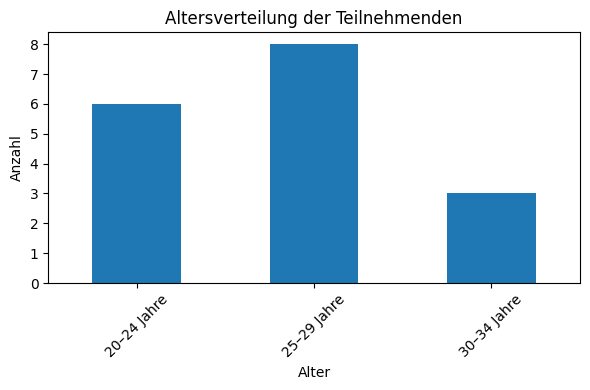

In [3]:
# Altersverteilung
plt.figure(figsize=(6,4))
df['Wie alt sind Sie?'].value_counts().sort_index().plot(kind='bar')
plt.title('Altersverteilung der Teilnehmenden')
plt.xlabel('Alter')
plt.ylabel('Anzahl')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

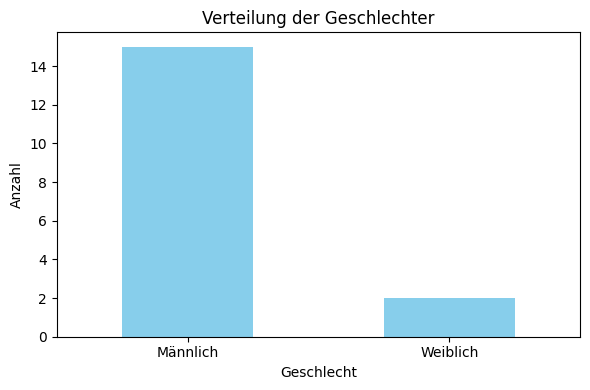

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Spalte für Geschlecht definieren
geschlecht_col = "Bitte geben Sie Ihr Geschlecht an"

# Häufigkeiten berechnen
geschlecht_counts = df[geschlecht_col].value_counts(dropna=False)

# Plot
plt.figure(figsize=(6,4))
geschlecht_counts.plot(kind="bar", color="skyblue")
plt.title("Verteilung der Geschlechter")
plt.xlabel("Geschlecht")
plt.ylabel("Anzahl")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


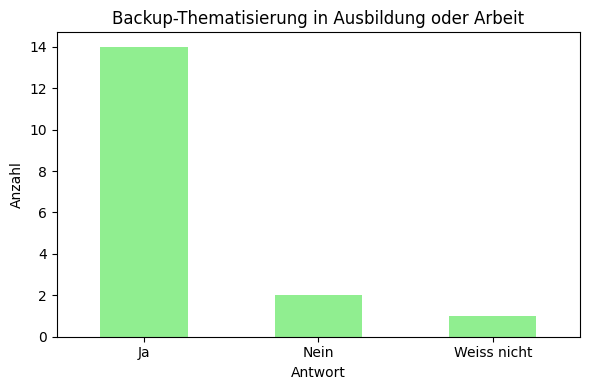

In [5]:
# Spaltenname definieren
backup_thematisiert_col = "Wurde das Thema Backup im Rahmen Ihrer Ausbildung oder Arbeit bereits thematisiert?"

# Häufigkeiten berechnen
backup_counts = df[backup_thematisiert_col].value_counts(dropna=False)

# Visualisierung
plt.figure(figsize=(6,4))
backup_counts.plot(kind="bar", color="lightgreen")
plt.title("Backup-Thematisierung in Ausbildung oder Arbeit")
plt.xlabel("Antwort")
plt.ylabel("Anzahl")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


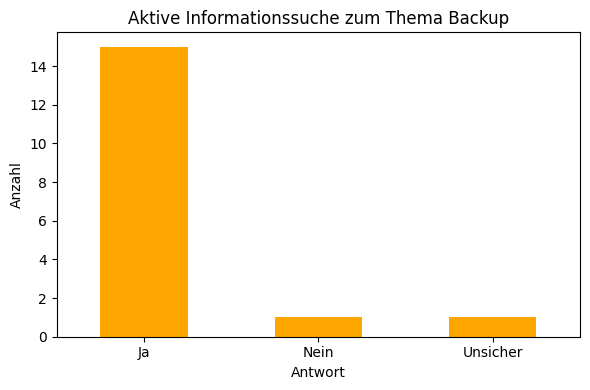

In [6]:
# Spaltenname definieren
info_suche_col = "Haben Sie jemals aktiv Informationen zum Thema Backup gesucht?"

# Häufigkeiten berechnen
info_suche_counts = df[info_suche_col].value_counts(dropna=False)

# Visualisierung
plt.figure(figsize=(6,4))
info_suche_counts.plot(kind="bar", color="orange")
plt.title("Aktive Informationssuche zum Thema Backup")
plt.xlabel("Antwort")
plt.ylabel("Anzahl")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


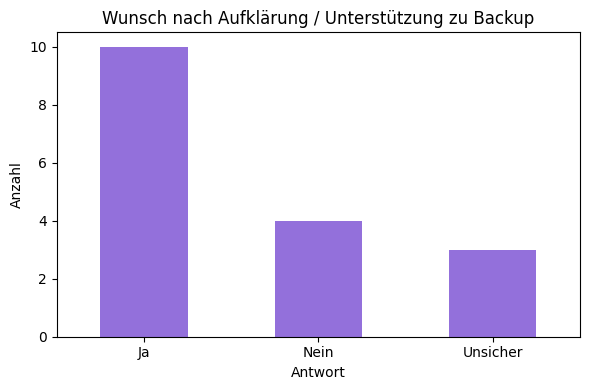

In [7]:
# Spaltenname definieren
aufklaerung_col = "Wünschen Sie sich mehr Aufklärung oder Unterstützung zum Thema Backup?"

# Häufigkeiten berechnen
aufklaerung_counts = df[aufklaerung_col].value_counts(dropna=False)

# Visualisierung
plt.figure(figsize=(6,4))
aufklaerung_counts.plot(kind="bar", color="mediumpurple")
plt.title("Wunsch nach Aufklärung / Unterstützung zu Backup")
plt.xlabel("Antwort")
plt.ylabel("Anzahl")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


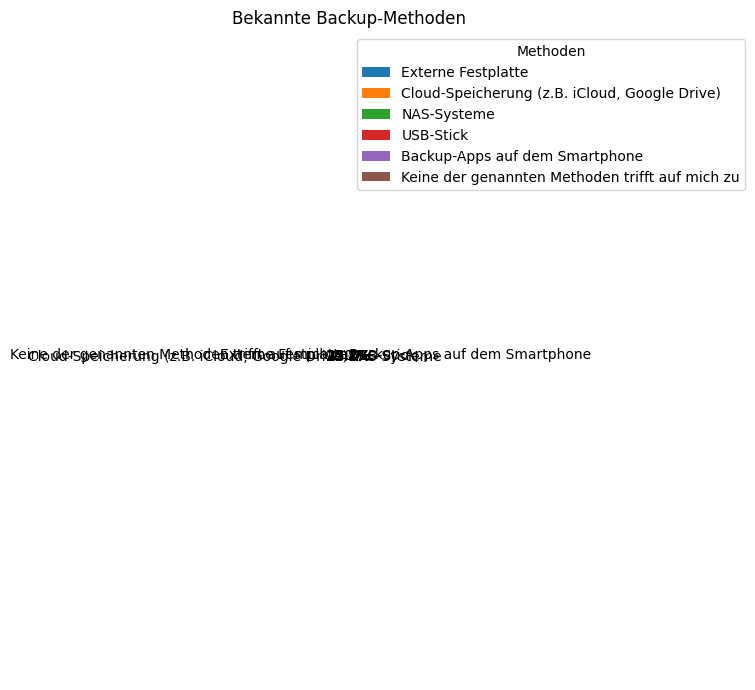

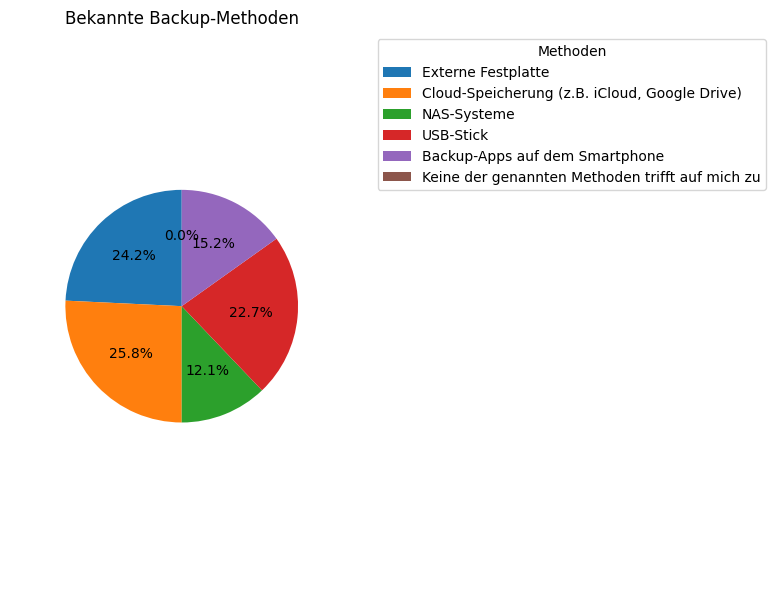

In [8]:
# Spaltenliste
backup_methoden_cols = [
    "Welche Backup-Methoden kennen Sie? [Externe Festplatte]",
    "Welche Backup-Methoden kennen Sie? [Cloud-Speicherung (z.B. iCloud, Google Drive)]",
    "Welche Backup-Methoden kennen Sie? [NAS-Systeme]",
    "Welche Backup-Methoden kennen Sie? [USB-Stick]",
    "Welche Backup-Methoden kennen Sie? [Backup-Apps auf dem Smartphone]",
    "Welche Backup-Methoden kennen Sie? [Keine der genannten Methoden trifft auf mich zu]"
]

# Antworten zählen
backup_counts = df[backup_methoden_cols].apply(lambda col: col.eq("Ja").sum())

# Diagramm
plt.figure(figsize=(7,7))
plt.pie(backup_counts, labels=backup_counts.index.str.extract(r'\[(.*)\]')[0], autopct='%1.1f%%', startangle=90)
plt.title("Bekannte Backup-Methoden")
plt.axis('equal')  # Kreisform beibehalten
plt.legend(title="Methoden", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()# Diagramm mit Labels nur in der Legende
plt.figure(figsize=(8,6))
wedges, _, _ = plt.pie(backup_counts, labels=[""]*len(backup_counts), autopct='%1.1f%%', startangle=90)

# Legende manuell aus den Index-Werten extrahieren
labels = backup_counts.index.str.extract(r'\[(.*)\]')[0]
plt.legend(wedges, labels, title="Methoden", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.title("Bekannte Backup-Methoden")
plt.axis('equal')
plt.tight_layout()
plt.show()



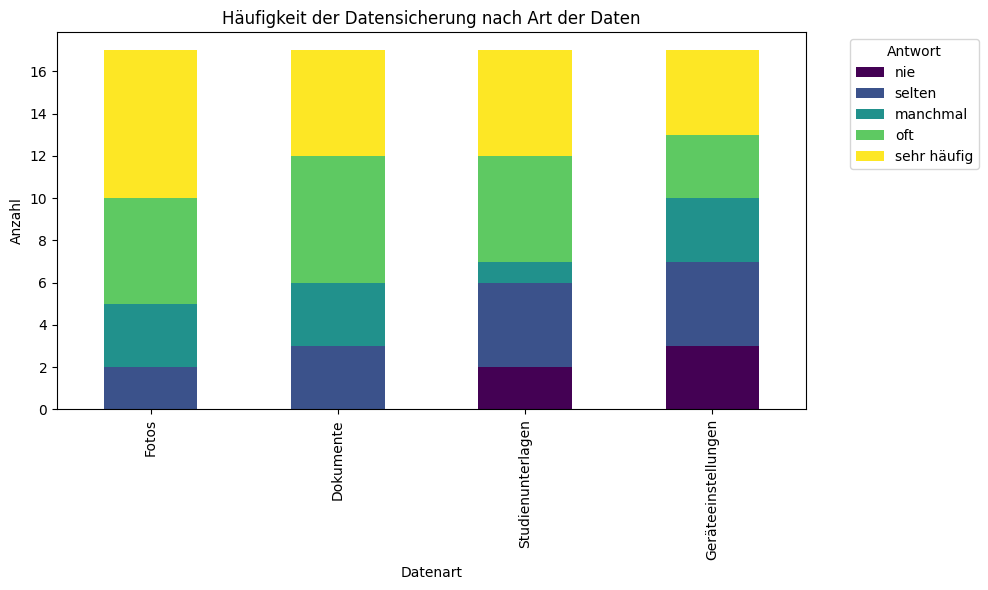

In [9]:
# Spaltennamen der Matrixfrage
backup_frequenz_cols = {
    "Fotos": "Wie häufig sichern Sie folgende Arten von Daten? [Fotos]",
    "Dokumente": "Wie häufig sichern Sie folgende Arten von Daten? [Dokumente]",
    "Studienunterlagen": "Wie häufig sichern Sie folgende Arten von Daten? [Studienunterlagen]",
    "Geräteeinstellungen": "Wie häufig sichern Sie folgende Arten von Daten? [Geräteeinstellungen]"
}

# Antwortreihenfolge definieren
antwortskala = ["nie", "selten", "manchmal", "oft", "sehr häufig"]

# Daten umformen
freq_data = df[list(backup_frequenz_cols.values())].replace({np.nan: "Fehlend"})
freq_df = pd.DataFrame()

for label, col in backup_frequenz_cols.items():
    counts = freq_data[col].value_counts().reindex(antwortskala, fill_value=0)
    freq_df[label] = counts

# Transponieren für gestapeltes Balkendiagramm
freq_df = freq_df.T

# Plot
freq_df.plot(kind="bar", stacked=True, figsize=(10,6), colormap="viridis")
plt.title("Häufigkeit der Datensicherung nach Art der Daten")
plt.xlabel("Datenart")
plt.ylabel("Anzahl")
plt.legend(title="Antwort", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


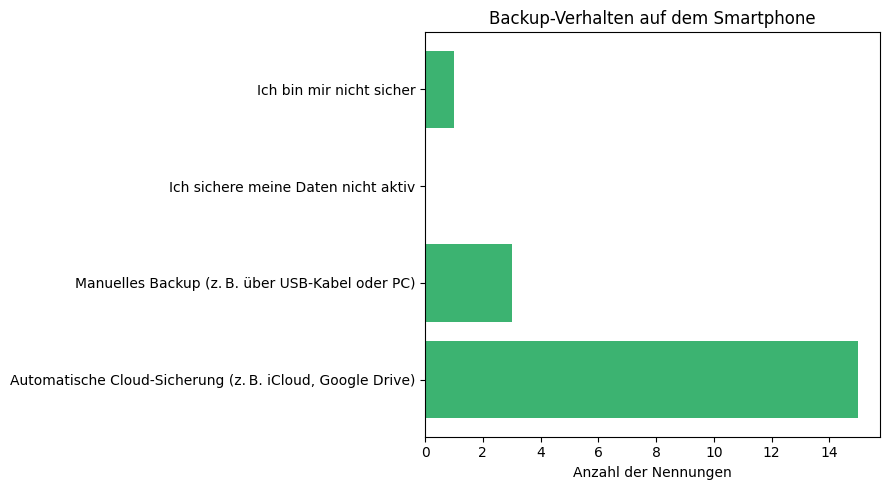

In [10]:
# Spaltenliste für alle Antwortoptionen
smartphone_backup_cols = [
    "Wie sichern Sie Daten auf Ihrem Smartphone? [Automatische Cloud-Sicherung (z. B. iCloud, Google Drive)]",
    "Wie sichern Sie Daten auf Ihrem Smartphone? [Manuelles Backup (z. B. über USB-Kabel oder PC)]",
    "Wie sichern Sie Daten auf Ihrem Smartphone? [Ich sichere meine Daten nicht aktiv]",
    "Wie sichern Sie Daten auf Ihrem Smartphone? [Ich bin mir nicht sicher]"
]

# Zählen der "Ja"-Antworten
smartphone_counts = df[smartphone_backup_cols].apply(lambda col: col.eq("Ja").sum())

# Labels extrahieren
labels = smartphone_counts.index.str.extract(r'\[(.*)\]')[0]

# Plot erstellen
plt.figure(figsize=(9,5))
plt.barh(labels, smartphone_counts.values, color="mediumseagreen")
plt.title("Backup-Verhalten auf dem Smartphone")
plt.xlabel("Anzahl der Nennungen")
plt.tight_layout()
plt.show()


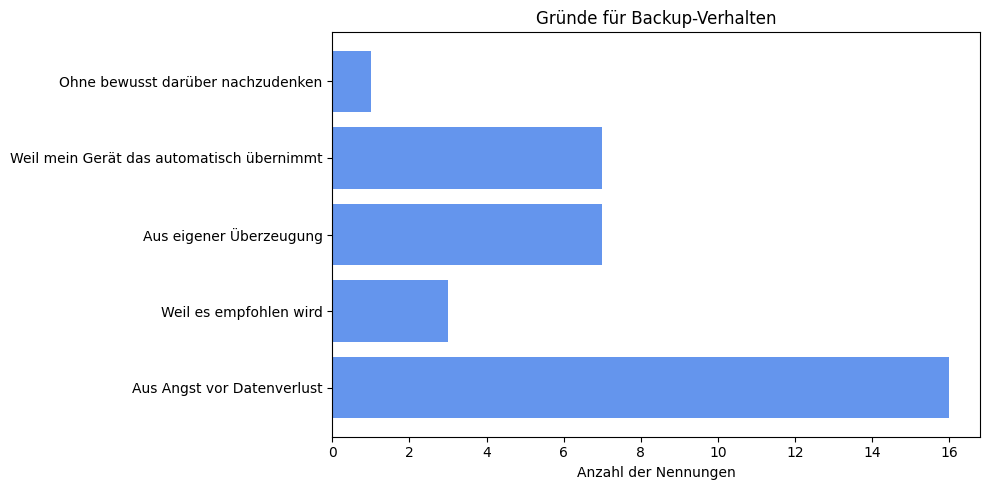

In [11]:
# Spalten der Mehrfachauswahlfrage
backup_gruende_cols = [
    "Warum machen Sie Backups? [Aus Angst vor Datenverlust]",
    "Warum machen Sie Backups? [Weil es empfohlen wird]",
    "Warum machen Sie Backups? [Aus eigener Überzeugung]",
    "Warum machen Sie Backups? [Weil mein Gerät das automatisch übernimmt]",
    "Warum machen Sie Backups? [Ohne bewusst darüber nachzudenken]"
]

# Zähle die "Ja"-Nennungen
backup_gruende_counts = df[backup_gruende_cols].apply(lambda col: col.eq("Ja").sum())

# Labels extrahieren
labels = backup_gruende_counts.index.str.extract(r'\[(.*)\]')[0]

# Plot
plt.figure(figsize=(10,5))
plt.barh(labels, backup_gruende_counts.values, color="cornflowerblue")
plt.title("Gründe für Backup-Verhalten")
plt.xlabel("Anzahl der Nennungen")
plt.tight_layout()
plt.show()


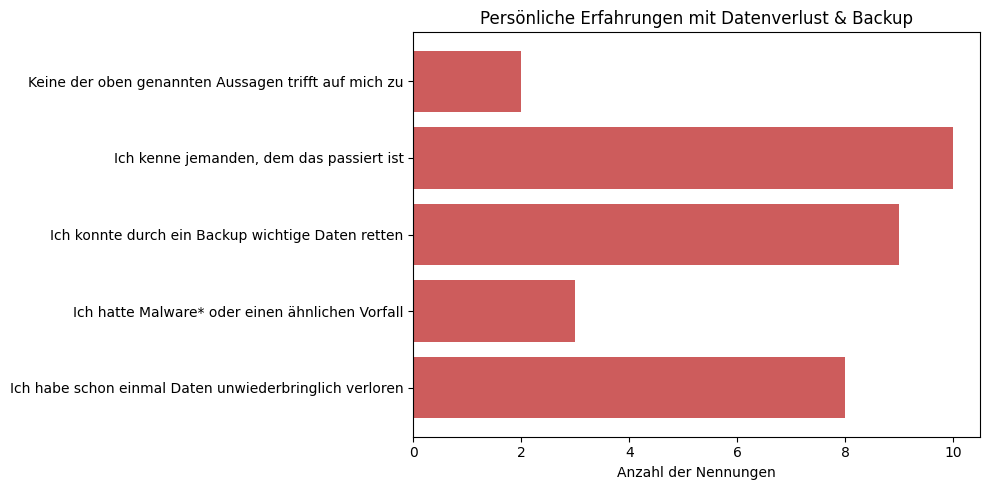

In [12]:
# Spalten der Mehrfachauswahlfrage
erfahrungen_cols = [
    "Welche dieser Aussagen treffen auf Sie zu? [Ich habe schon einmal Daten unwiederbringlich verloren]",
    "Welche dieser Aussagen treffen auf Sie zu? [Ich hatte Malware* oder einen ähnlichen Vorfall]",
    "Welche dieser Aussagen treffen auf Sie zu? [Ich konnte durch ein Backup wichtige Daten retten]",
    "Welche dieser Aussagen treffen auf Sie zu? [Ich kenne jemanden, dem das passiert ist]",
    "Welche dieser Aussagen treffen auf Sie zu? [Keine der oben genannten Aussagen trifft auf mich zu]"
]

# Zähle die "Ja"-Antworten
erfahrungen_counts = df[erfahrungen_cols].apply(lambda col: col.eq("Ja").sum())

# Labels extrahieren
labels = erfahrungen_counts.index.str.extract(r'\[(.*)\]')[0]

# Plot
plt.figure(figsize=(10,5))
plt.barh(labels, erfahrungen_counts.values, color="indianred")
plt.title("Persönliche Erfahrungen mit Datenverlust & Backup")
plt.xlabel("Anzahl der Nennungen")
plt.tight_layout()
plt.show()


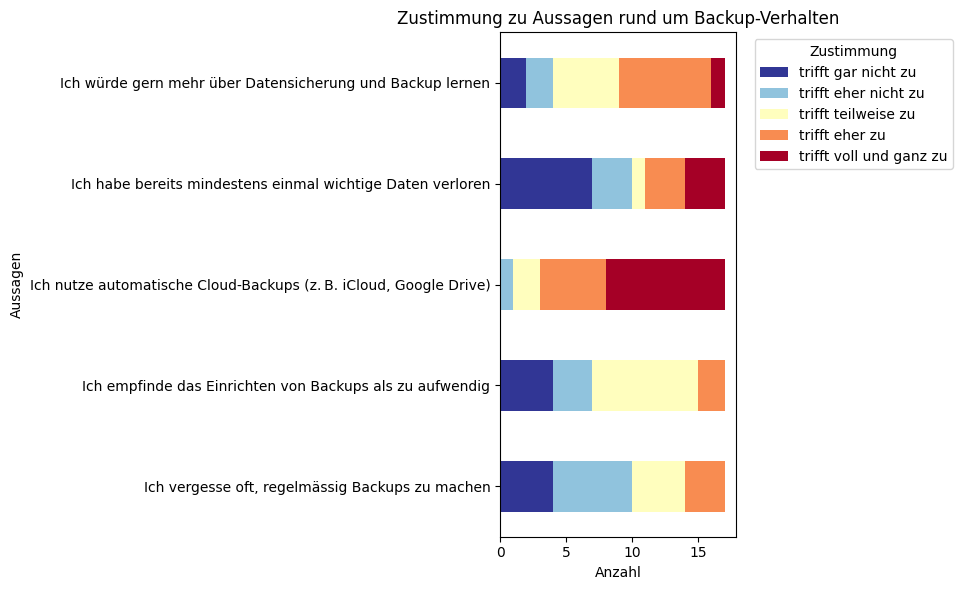

In [13]:
# Relevante Spalten der Matrixfrage
zustimmung_cols = {
    "Ich vergesse oft, regelmässig Backups zu machen": "Wie sehr stimmen Sie folgenden Aussagen zu? [Ich vergesse oft, regelmässig Backups zu machen]",
    "Ich empfinde das Einrichten von Backups als zu aufwendig": "Wie sehr stimmen Sie folgenden Aussagen zu? [Ich empfinde das Einrichten von Backups als zu aufwendig]",
    "Ich nutze automatische Cloud-Backups (z. B. iCloud, Google Drive)": "Wie sehr stimmen Sie folgenden Aussagen zu? [Ich nutze automatische Cloud-Backups (z. B. iCloud, Google Drive)]",
    "Ich habe bereits mindestens einmal wichtige Daten verloren": "Wie sehr stimmen Sie folgenden Aussagen zu? [Ich habe bereits mindestens einmal wichtige Daten verloren]",
    "Ich würde gern mehr über Datensicherung und Backup lernen": "Wie sehr stimmen Sie folgenden Aussagen zu? [Ich würde gern mehr über Datensicherung und Backup lernen]"
}

# Antwortoptionen in gewünschter Reihenfolge
zustimmung_skala = [
    "trifft gar nicht zu",
    "trifft eher nicht zu",
    "trifft teilweise zu",
    "trifft eher zu",
    "trifft voll und ganz zu"
]

# Antworten zählen
zustimmung_df = pd.DataFrame()
for item, col in zustimmung_cols.items():
    zustimmung_df[item] = df[col].value_counts().reindex(zustimmung_skala, fill_value=0)

# Transponieren für Plot
zustimmung_df = zustimmung_df.T

# Plot
zustimmung_df.plot(kind="barh", stacked=True, figsize=(10,6), colormap="RdYlBu_r")
plt.title("Zustimmung zu Aussagen rund um Backup-Verhalten")
plt.xlabel("Anzahl")
plt.ylabel("Aussagen")
plt.legend(title="Zustimmung", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


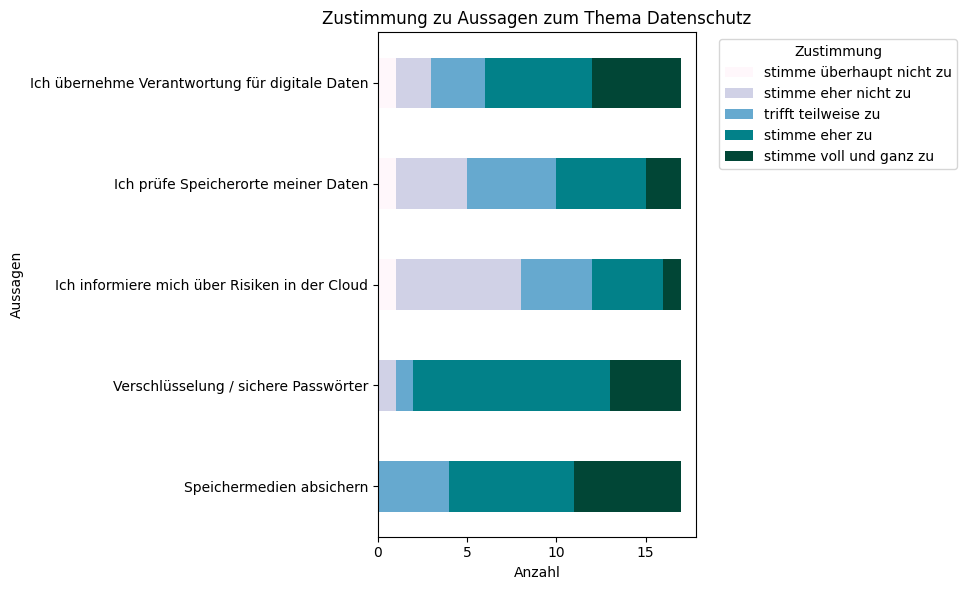

In [14]:
# Spalten der Matrixfrage zum Datenschutz
datenschutz_cols = {
    "Speichermedien absichern": "Wie sehr stimmen Sie den folgenden Aussagen zum Thema Datenschutz zu? [Ich achte darauf, dass meine Speichermedien (z. B. USB-Stick, externe Festplatte) sicher sind]",
    "Verschlüsselung / sichere Passwörter": "Wie sehr stimmen Sie den folgenden Aussagen zum Thema Datenschutz zu? [Ich verwende Verschlüsselung oder sichere Passwörter zum Schutz meiner Daten]",
    "Ich informiere mich über Risiken in der Cloud": "Wie sehr stimmen Sie den folgenden Aussagen zum Thema Datenschutz zu? [Ich informiere mich regelmässig über Datenschutzrisiken in der Cloud]",
    "Ich prüfe Speicherorte meiner Daten": "Wie sehr stimmen Sie den folgenden Aussagen zum Thema Datenschutz zu? [Ich prüfe regelmässig, wo und wie meine persönlichen Daten gespeichert sind]",
    "Ich übernehme Verantwortung für digitale Daten": "Wie sehr stimmen Sie den folgenden Aussagen zum Thema Datenschutz zu? [Ich übernehme bewusst Verantwortung für den Schutz meiner digitalen Daten]"
}

# Antwortreihenfolge
zustimmung_skala = [
    "stimme überhaupt nicht zu",
    "stimme eher nicht zu",
    "trifft teilweise zu",
    "stimme eher zu",
    "stimme voll und ganz zu"
]

# Antworten zählen
datenschutz_df = pd.DataFrame()
for item, col in datenschutz_cols.items():
    datenschutz_df[item] = df[col].value_counts().reindex(zustimmung_skala, fill_value=0)

# Transponieren für Plot
datenschutz_df = datenschutz_df.T

# Plot
datenschutz_df.plot(kind="barh", stacked=True, figsize=(10,6), colormap="PuBuGn")
plt.title("Zustimmung zu Aussagen zum Thema Datenschutz")
plt.xlabel("Anzahl")
plt.ylabel("Aussagen")
plt.legend(title="Zustimmung", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


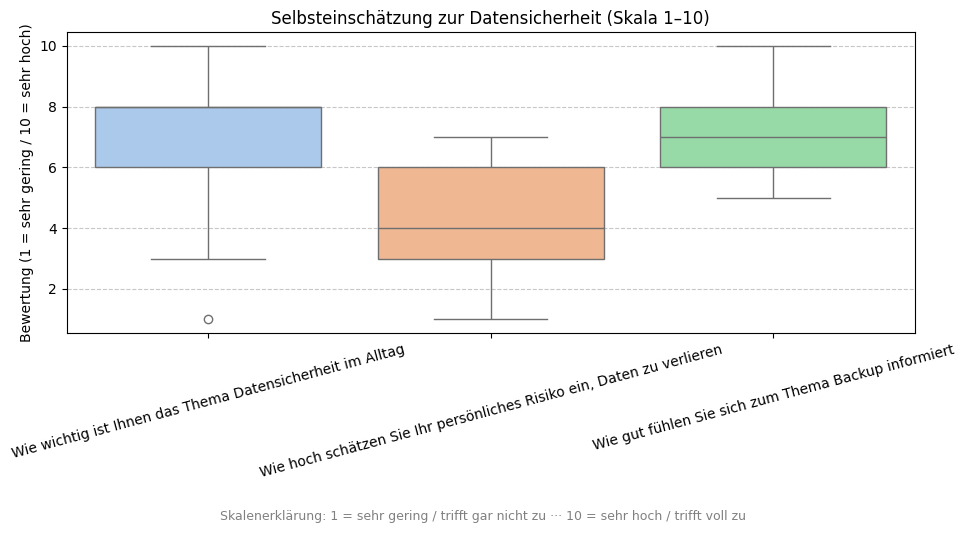

In [15]:
# Spaltennamen definieren
datensicherheit_cols = [
    "Wie schätzen Sie Ihre persönliche Haltung zum Thema Datensicherheit ein? [Wie wichtig ist Ihnen das Thema Datensicherheit im Alltag?]",
    "Wie schätzen Sie Ihre persönliche Haltung zum Thema Datensicherheit ein? [Wie hoch schätzen Sie Ihr persönliches Risiko ein, Daten zu verlieren?]",
    "Wie schätzen Sie Ihre persönliche Haltung zum Thema Datensicherheit ein? [Wie gut fühlen Sie sich zum Thema Backup informiert?]"
]

# Daten vorbereiten
df_box = df[datensicherheit_cols].rename(columns=lambda c: c.split("[")[1].replace("?", "").replace("]", "").strip())

# Plot
plt.figure(figsize=(10,5))
sns.boxplot(data=df_box, palette="pastel")
plt.title("Selbsteinschätzung zur Datensicherheit (Skala 1–10)")
plt.ylabel("Bewertung (1 = sehr gering / 10 = sehr hoch)")
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.figtext(0.5, -0.05, "Skalenerklärung: 1 = sehr gering / trifft gar nicht zu ··· 10 = sehr hoch / trifft voll zu", 
            ha="center", fontsize=9, color="gray")
plt.show()


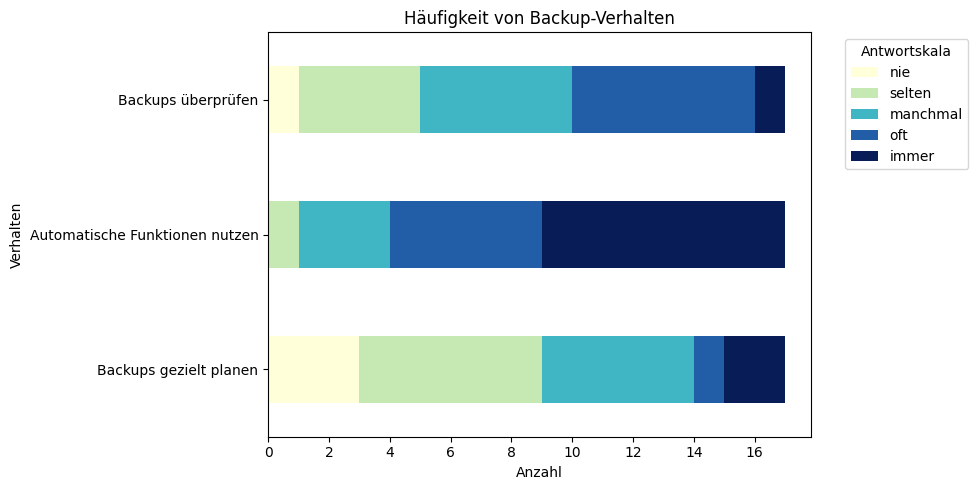

In [16]:
# Spalten der Matrixfrage definieren
verhalten_cols = {
    "Backups gezielt planen": "Wie häufig tun Sie Folgendes im Umgang mit Datensicherung? [Ich plane Backups gezielt und regelmässig ein]",
    "Automatische Funktionen nutzen": "Wie häufig tun Sie Folgendes im Umgang mit Datensicherung? [Ich nutze automatische Funktionen zur Datensicherung (z. B. Cloud-Backup)]",
    "Backups überprüfen": "Wie häufig tun Sie Folgendes im Umgang mit Datensicherung? [Ich überprüfe regelmässig, ob Backups erfolgreich durchgeführt wurden]"
}

# Antwortskala in logischer Reihenfolge
antworten = ["nie", "selten", "manchmal", "oft", "immer"]

# Antworten zählen
verhalten_df = pd.DataFrame()
for item, col in verhalten_cols.items():
    verhalten_df[item] = df[col].value_counts().reindex(antworten, fill_value=0)

# Transponieren für Plot
verhalten_df = verhalten_df.T

# Plot
verhalten_df.plot(kind="barh", stacked=True, figsize=(10,5), colormap="YlGnBu")
plt.title("Häufigkeit von Backup-Verhalten")
plt.xlabel("Anzahl")
plt.ylabel("Verhalten")
plt.legend(title="Antwortskala", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


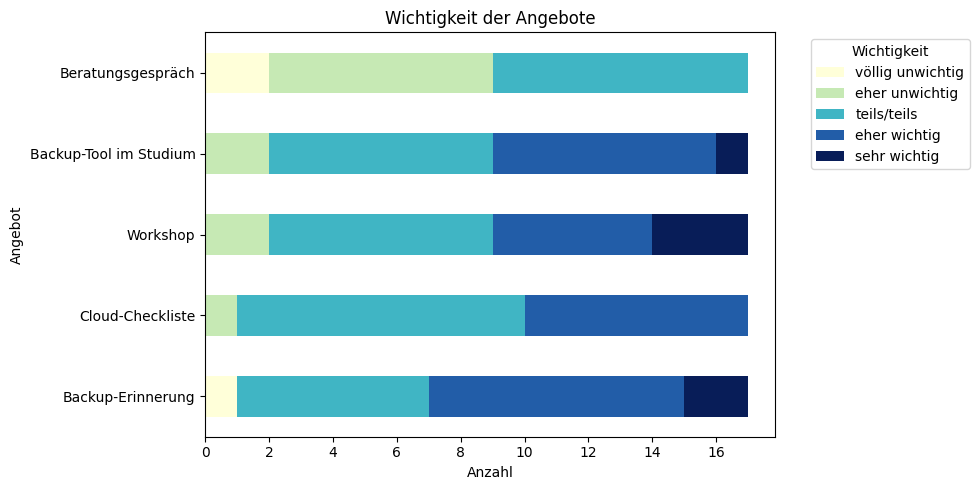

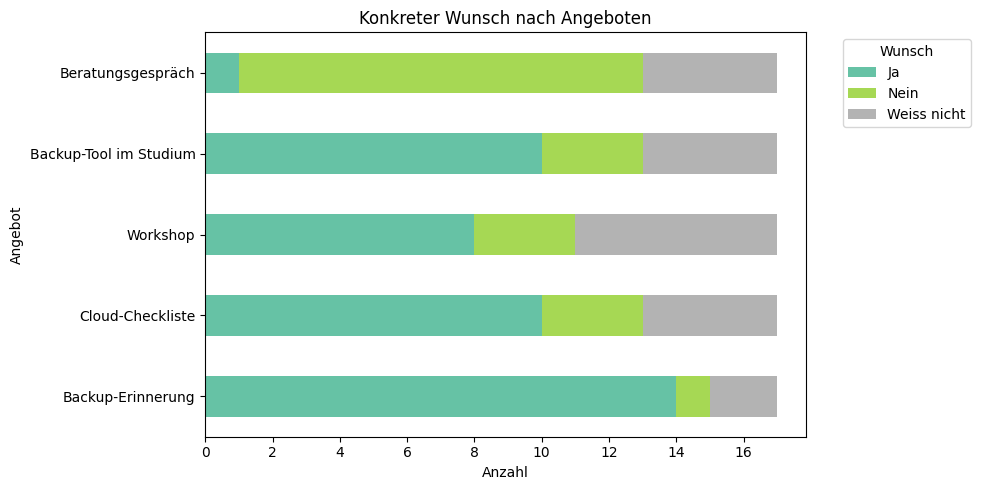

In [17]:
# Spaltennamen definieren
angebote = {
    "Backup-Erinnerung": ("Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Backup-Erinnerung][Skala 1]",
                          "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Backup-Erinnerung][Skala 2]"),
    "Cloud-Checkliste": ("Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Cloud-Checkliste zur Selbstkontrolle][Skala 1]",
                         "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Cloud-Checkliste zur Selbstkontrolle][Skala 2]"),
    "Workshop": ("Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Workshop zur Datensicherheit][Skala 1]",
                 "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Workshop zur Datensicherheit][Skala 2]"),
    "Backup-Tool im Studium": ("Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Integriertes Backup-Tool im Studium][Skala 1]",
                               "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Integriertes Backup-Tool im Studium][Skala 2]"),
    "Beratungsgespräch": ("Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Persönliches Beratungsgespräch][Skala 1]",
                          "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Persönliches Beratungsgespräch][Skala 2]")
}

# Antwortstufen
wichtigkeit_stufen = ["völlig unwichtig", "eher unwichtig", "teils/teils", "eher wichtig", "sehr wichtig"]
wunsch_stufen = ["Ja", "Nein", "Weiss nicht"]

# Wichtigkeit aggregieren
df_wichtigkeit = pd.DataFrame()
for item, (wichtigkeit, _) in angebote.items():
    df_wichtigkeit[item] = df[wichtigkeit].value_counts().reindex(wichtigkeit_stufen, fill_value=0)
df_wichtigkeit = df_wichtigkeit.T

# Wunsch aggregieren
df_wunsch = pd.DataFrame()
for item, (_, wunsch) in angebote.items():
    df_wunsch[item] = df[wunsch].value_counts().reindex(wunsch_stufen, fill_value=0)
df_wunsch = df_wunsch.T

# Plot 1: Wichtigkeit
plt.figure(figsize=(10, 5))
df_wichtigkeit.plot(kind="barh", stacked=True, colormap="YlGnBu", ax=plt.gca())
plt.title("Wichtigkeit der Angebote")
plt.xlabel("Anzahl")
plt.ylabel("Angebot")
plt.legend(title="Wichtigkeit", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot 2: Wunsch
plt.figure(figsize=(10, 5))
df_wunsch.plot(kind="barh", stacked=True, colormap="Set2", ax=plt.gca())
plt.title("Konkreter Wunsch nach Angeboten")
plt.xlabel("Anzahl")
plt.ylabel("Angebot")
plt.legend(title="Wunsch", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


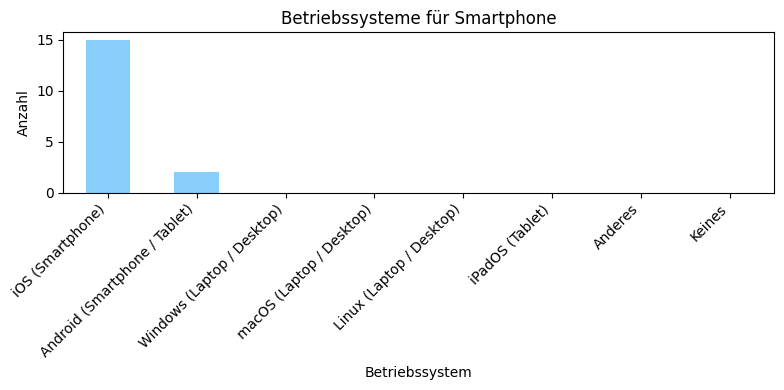

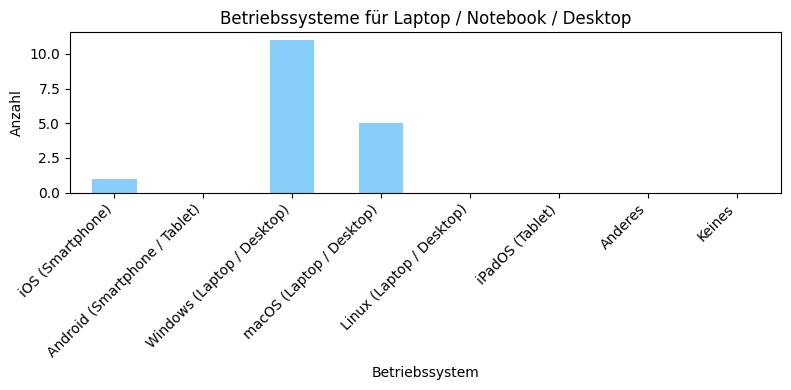

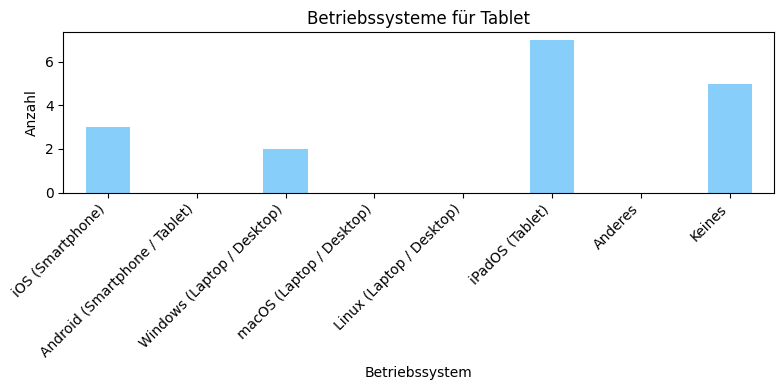

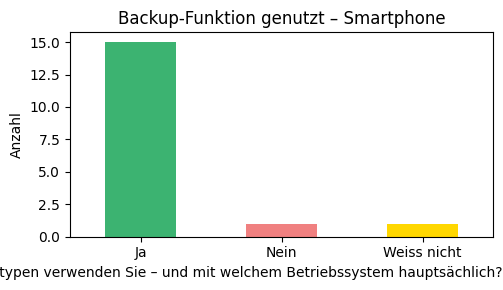

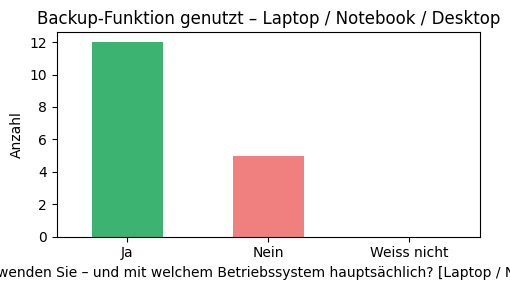

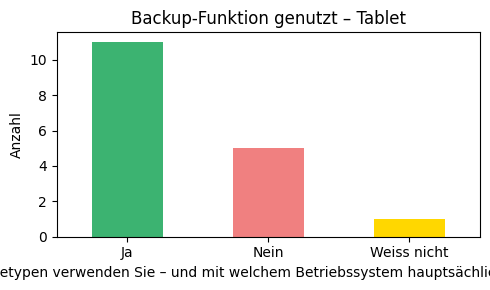

In [18]:
# Gerätetypen und Betriebssysteme
geraete_os = {
    "Smartphone": [
        "Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Smartphone][Skala 1]",
        "Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Smartphone][Skala 2]"
    ],
    "Laptop / Notebook / Desktop": [
        "Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Laptop / Notebook / Desktop][Skala 1]",
        "Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Laptop / Notebook / Desktop][Skala 2]"
    ],
    "Tablet": [
        "Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Tablet][Skala 1]",
        "Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Tablet][Skala 2]"
    ]
}

# Alle OS-Kategorien (vereinheitlicht)
os_kategorien = ["iOS (Smartphone)", "Android (Smartphone / Tablet)", "Windows (Laptop / Desktop)",
                 "macOS (Laptop / Desktop)", "Linux (Laptop / Desktop)", "iPadOS (Tablet)", "Anderes", "Keines"]

# Plot: Betriebssystemverteilung pro Gerätetyp
for geraet, (os_col, _) in geraete_os.items():
    os_counts = df[os_col].value_counts().reindex(os_kategorien, fill_value=0)
    plt.figure(figsize=(8,4))
    os_counts.plot(kind="bar", color="lightskyblue")
    plt.title(f"Betriebssysteme für {geraet}")
    plt.ylabel("Anzahl")
    plt.xlabel("Betriebssystem")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Plot: Backup-Nutzung pro Gerätetyp
for geraet, (_, backup_col) in geraete_os.items():
    backup_counts = df[backup_col].value_counts().reindex(["Ja", "Nein", "Weiss nicht"], fill_value=0)
    plt.figure(figsize=(5,3))
    backup_counts.plot(kind="bar", color=["mediumseagreen", "lightcoral", "gold"])
    plt.title(f"Backup-Funktion genutzt – {geraet}")
    plt.ylabel("Anzahl")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


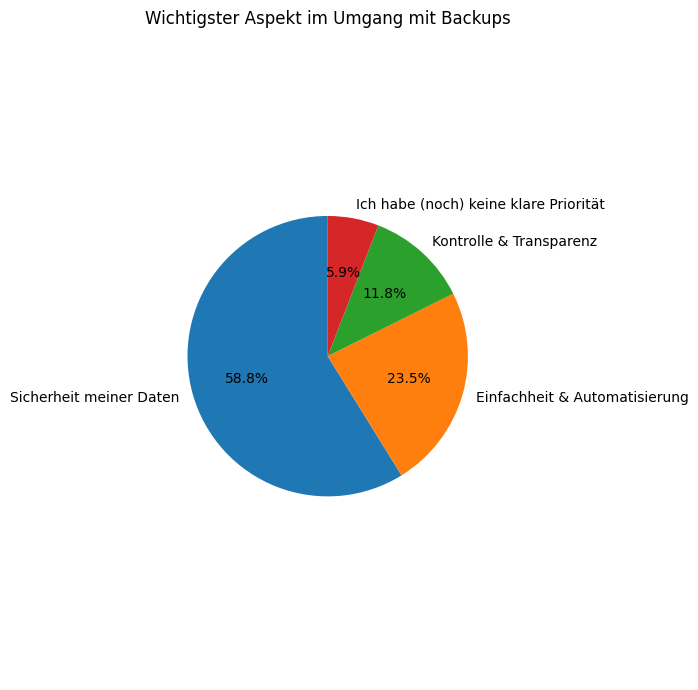

In [19]:
# Spalte definieren
aspekt_col = "Welcher dieser Aspekte ist für Sie persönlich am wichtigsten im Umgang mit Backups?"

# Zähle die Nennungen
aspekt_counts = df[aspekt_col].value_counts(dropna=False)

# Plot
plt.figure(figsize=(7,7))
plt.pie(aspekt_counts, labels=aspekt_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Wichtigster Aspekt im Umgang mit Backups")
plt.axis("equal")  # Kreisform
plt.tight_layout()
plt.show()


## 3. Gruppenvergleiche alter

📈 Spearman-Korrelation Alter ~ Wichtigkeit: ρ = 0.27, p = 0.294
📈 Spearman-Korrelation Alter ~ Informationsstand: ρ = 0.16, p = 0.543


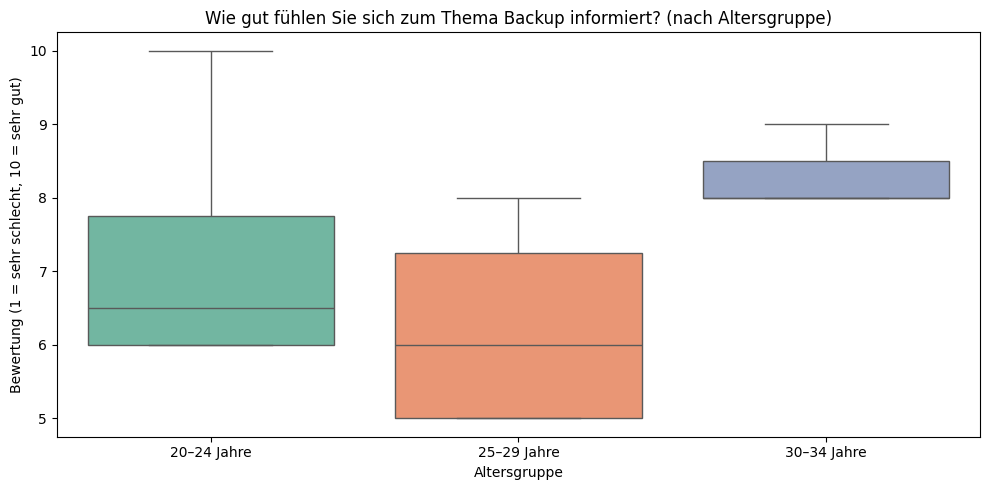

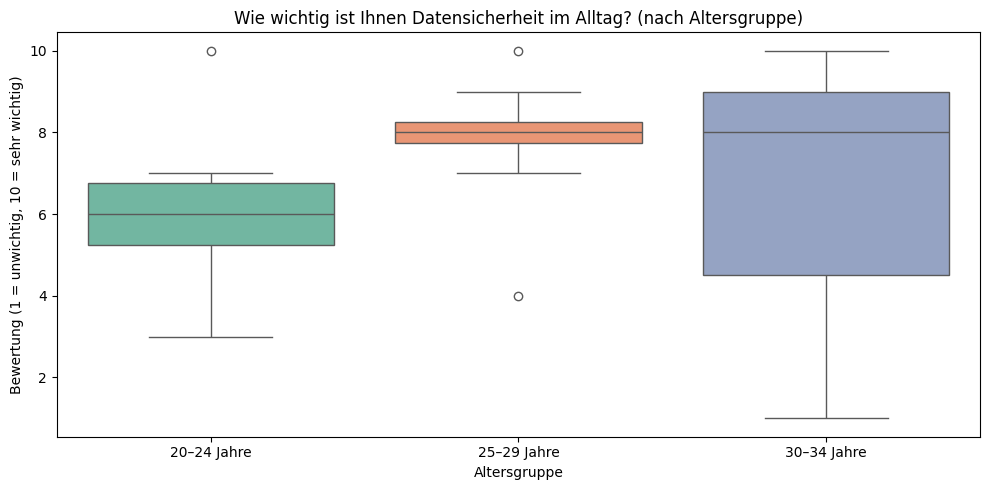

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Spalten definieren
alter_col = "Wie alt sind Sie?"
wichtigkeit_col = "Wie schätzen Sie Ihre persönliche Haltung zum Thema Datensicherheit ein? [Wie wichtig ist Ihnen das Thema Datensicherheit im Alltag?]"
wissen_col = "Wie schätzen Sie Ihre persönliche Haltung zum Thema Datensicherheit ein? [Wie gut fühlen Sie sich zum Thema Backup informiert?]"

# Daten extrahieren und bereinigen
df_schaetzung = df[[alter_col, wichtigkeit_col, wissen_col]].dropna()
df_schaetzung[wichtigkeit_col] = pd.to_numeric(df_schaetzung[wichtigkeit_col], errors="coerce")
df_schaetzung[wissen_col] = pd.to_numeric(df_schaetzung[wissen_col], errors="coerce")

# Altersgruppen übernehmen (bereits gruppiert)
gruppen_reihenfolge = ["20–24 Jahre", "25–29 Jahre", "30–34 Jahre"]
df_schaetzung["Altersgruppe"] = pd.Categorical(df_schaetzung[alter_col], categories=gruppen_reihenfolge, ordered=True)

# 1. Korrelation mit Altersgruppen als ordinal skaliert behandeln (nur grob!)
# Optional: für Korrelation numerisch mappen
alter_map = {"20–24 Jahre": 1, "25–29 Jahre": 2, "30–34 Jahre": 3}
df_schaetzung["Alter_num"] = df_schaetzung["Altersgruppe"].map(alter_map)

# Spearman-Korrelationen berechnen
corr_wichtigkeit, p1 = spearmanr(df_schaetzung["Alter_num"], df_schaetzung[wichtigkeit_col])
corr_wissen, p2 = spearmanr(df_schaetzung["Alter_num"], df_schaetzung[wissen_col])

print(f"📈 Spearman-Korrelation Alter ~ Wichtigkeit: ρ = {corr_wichtigkeit:.2f}, p = {p1:.3f}")
print(f"📈 Spearman-Korrelation Alter ~ Informationsstand: ρ = {corr_wissen:.2f}, p = {p2:.3f}")

# 2. Visualisierung: Boxplots

# Boxplot: Informationsstand
plt.figure(figsize=(10,5))
sns.boxplot(data=df_schaetzung, x="Altersgruppe", y=wissen_col, palette="Set2", fill=True)
plt.title("Wie gut fühlen Sie sich zum Thema Backup informiert? (nach Altersgruppe)")
plt.ylabel("Bewertung (1 = sehr schlecht, 10 = sehr gut)")
plt.xlabel("Altersgruppe")
plt.tight_layout()
plt.show()

# Boxplot: Wichtigkeit
plt.figure(figsize=(10,5))
sns.boxplot(data=df_schaetzung, x="Altersgruppe", y=wichtigkeit_col, palette="Set2", fill=True)
plt.title("Wie wichtig ist Ihnen Datensicherheit im Alltag? (nach Altersgruppe)")
plt.ylabel("Bewertung (1 = unwichtig, 10 = sehr wichtig)")
plt.xlabel("Altersgruppe")
plt.tight_layout()
plt.show()


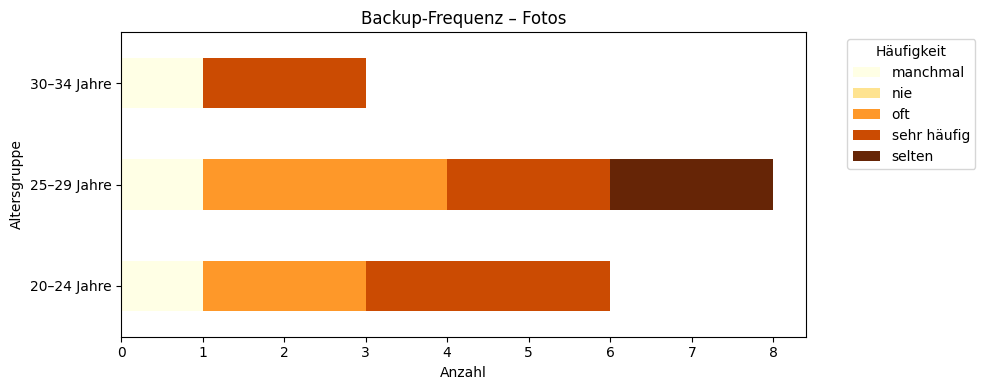

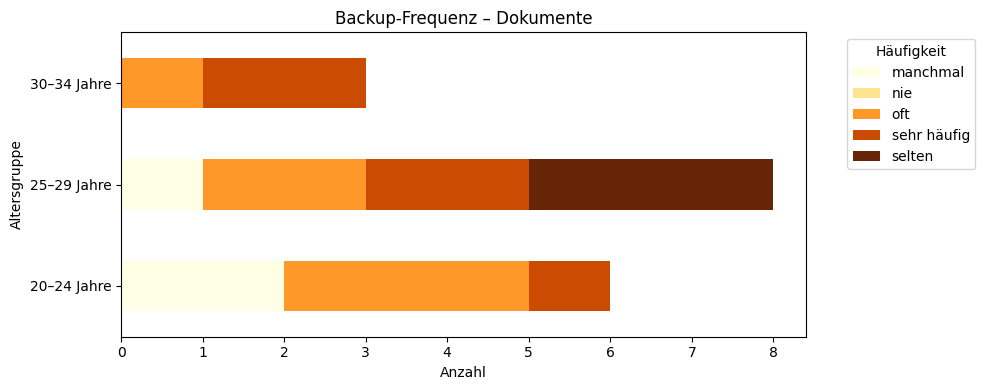

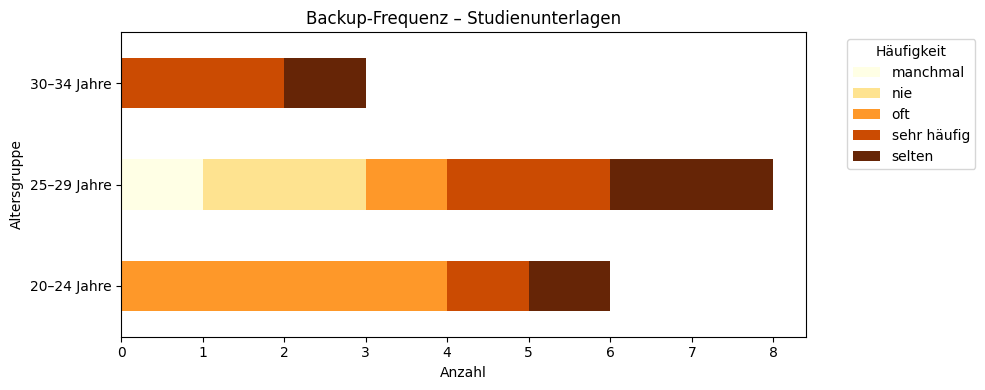

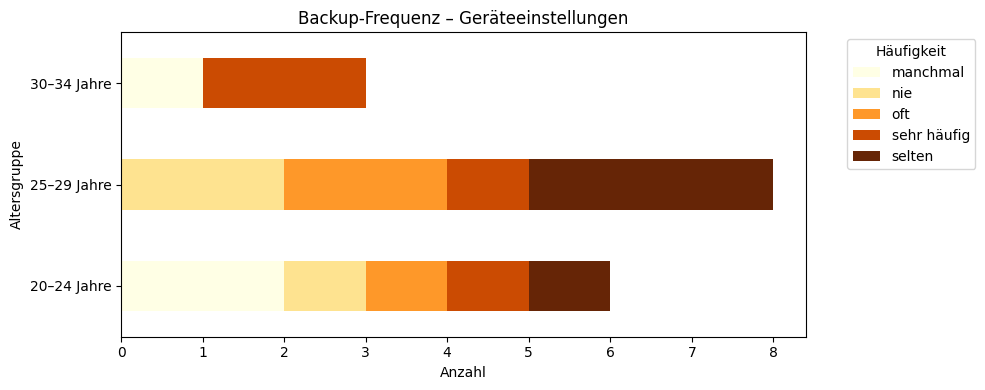

In [21]:
# Relevante Spalten für Backup-Frequenz
backup_frequenz_cols = {
    "Fotos": "Wie häufig sichern Sie folgende Arten von Daten? [Fotos]",
    "Dokumente": "Wie häufig sichern Sie folgende Arten von Daten? [Dokumente]",
    "Studienunterlagen": "Wie häufig sichern Sie folgende Arten von Daten? [Studienunterlagen]",
    "Geräteeinstellungen": "Wie häufig sichern Sie folgende Arten von Daten? [Geräteeinstellungen]"
}

# Antwortreihenfolge
antwortskala = ["nie", "selten", "manchmal", "oft", "sehr häufig"]

# Altersgruppen verwenden (wie vorher definiert)
gruppen_reihenfolge = ["20–24 Jahre", "25–29 Jahre", "30–34 Jahre"]
df["Altersgruppe"] = pd.Categorical(df["Wie alt sind Sie?"], categories=gruppen_reihenfolge, ordered=True)

# Aggregation: Für jede Datenart und Altersgruppe die Häufigkeit je Antwortstufe zählen
freq_long = []

for datentyp, spalte in backup_frequenz_cols.items():
    for gruppe in gruppen_reihenfolge:
        daten = df[df["Altersgruppe"] == gruppe][spalte]
        verteilung = daten.value_counts().reindex(antwortskala, fill_value=0)
        for antwort, anz in verteilung.items():
            freq_long.append({"Datenart": datentyp, "Antwort": antwort, "Altersgruppe": gruppe, "Anzahl": anz})

freq_df = pd.DataFrame(freq_long)

# Pivot für stacked barplot
plot_df = freq_df.pivot_table(index=["Datenart", "Altersgruppe"], columns="Antwort", values="Anzahl", fill_value=0)

# Plot
import matplotlib.pyplot as plt

for datentyp in backup_frequenz_cols.keys():
    plot_df.loc[datentyp].plot(kind="barh", stacked=True, figsize=(10,4), colormap="YlOrBr")
    plt.title(f"Backup-Frequenz – {datentyp}")
    plt.xlabel("Anzahl")
    plt.ylabel("Altersgruppe")
    plt.legend(title="Häufigkeit", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


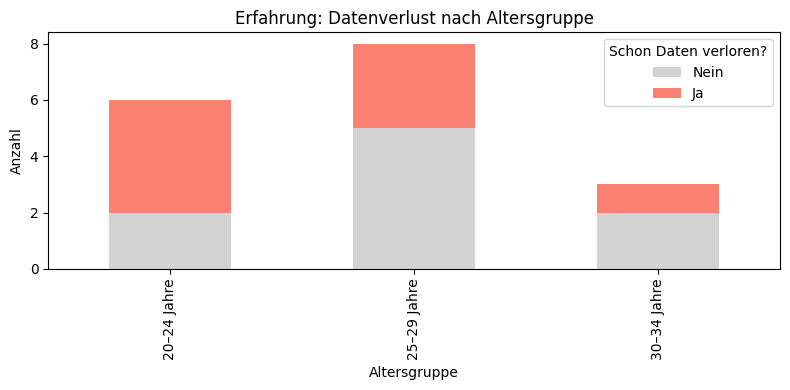

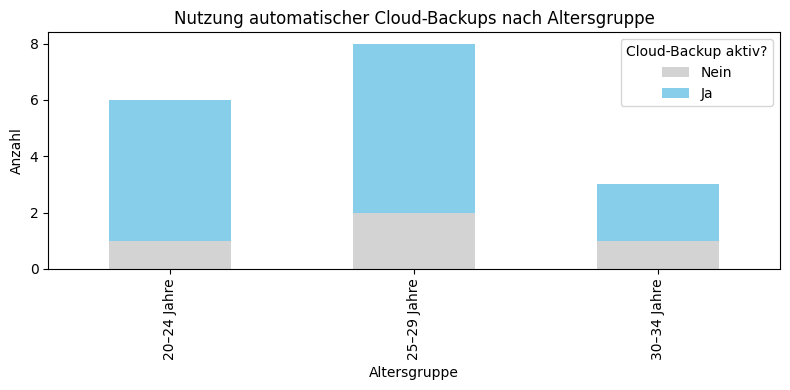

In [22]:
# Spaltennamen definieren
verlust_col = "Welche dieser Aussagen treffen auf Sie zu? [Ich habe schon einmal Daten unwiederbringlich verloren]"
cloudbackup_col = "Wie häufig tun Sie Folgendes im Umgang mit Datensicherung? [Ich nutze automatische Funktionen zur Datensicherung (z. B. Cloud-Backup)]"
altergruppe_col = "Wie alt sind Sie?"

# Altersgruppen setzen
gruppen_reihenfolge = ["20–24 Jahre", "25–29 Jahre", "30–34 Jahre"]
df["Altersgruppe"] = pd.Categorical(df[altergruppe_col], categories=gruppen_reihenfolge, ordered=True)

# Antwortspalten vereinheitlichen
df["Verlust"] = df[verlust_col].eq("Ja")
df["CloudBackup"] = df[cloudbackup_col].eq("immer") | df[cloudbackup_col].eq("oft")  # hohe Nutzung

# Aggregation nach Altersgruppe
verlust_counts = df.groupby("Altersgruppe")["Verlust"].value_counts().unstack().fillna(0)
cloud_counts = df.groupby("Altersgruppe")["CloudBackup"].value_counts().unstack().fillna(0)

# Plot 1: Datenverlust
verlust_counts.plot(kind="bar", stacked=True, figsize=(8,4), color=["lightgray", "salmon"])
plt.title("Erfahrung: Datenverlust nach Altersgruppe")
plt.ylabel("Anzahl")
plt.xlabel("Altersgruppe")
plt.legend(["Nein", "Ja"], title="Schon Daten verloren?")
plt.tight_layout()
plt.show()

# Plot 2: Nutzung von Cloud-Backups
cloud_counts.plot(kind="bar", stacked=True, figsize=(8,4), color=["lightgray", "skyblue"])
plt.title("Nutzung automatischer Cloud-Backups nach Altersgruppe")
plt.ylabel("Anzahl")
plt.xlabel("Altersgruppe")
plt.legend(["Nein", "Ja"], title="Cloud-Backup aktiv?")
plt.tight_layout()
plt.show()


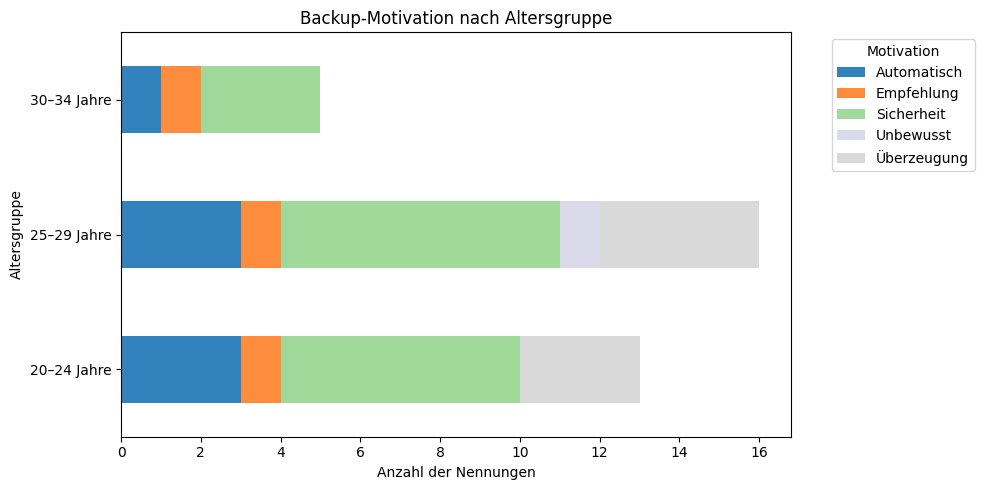

In [23]:
# Relevante Spalten der Mehrfachauswahlfrage
motivation_cols = {
    "Sicherheit": "Warum machen Sie Backups? [Aus Angst vor Datenverlust]",
    "Empfehlung": "Warum machen Sie Backups? [Weil es empfohlen wird]",
    "Überzeugung": "Warum machen Sie Backups? [Aus eigener Überzeugung]",
    "Automatisch": "Warum machen Sie Backups? [Weil mein Gerät das automatisch übernimmt]",
    "Unbewusst": "Warum machen Sie Backups? [Ohne bewusst darüber nachzudenken]"
}

# Altersgruppen verwenden
gruppen_reihenfolge = ["20–24 Jahre", "25–29 Jahre", "30–34 Jahre"]
df["Altersgruppe"] = pd.Categorical(df["Wie alt sind Sie?"], categories=gruppen_reihenfolge, ordered=True)

# Aggregation: Für jede Motivation die Anzahl der "Ja" nach Altersgruppe zählen
motivation_long = []

for motiv, col in motivation_cols.items():
    for gruppe in gruppen_reihenfolge:
        count = df[df["Altersgruppe"] == gruppe][col].eq("Ja").sum()
        motivation_long.append({"Motiv": motiv, "Altersgruppe": gruppe, "Anzahl": count})

# In DataFrame umwandeln
motivation_df = pd.DataFrame(motivation_long)

# Pivot für gestapelten Balkenplot
pivot_df = motivation_df.pivot(index="Altersgruppe", columns="Motiv", values="Anzahl").fillna(0)

# Plot
pivot_df.plot(kind="barh", stacked=True, figsize=(10,5), colormap="tab20c")
plt.title("Backup-Motivation nach Altersgruppe")
plt.xlabel("Anzahl der Nennungen")
plt.ylabel("Altersgruppe")
plt.legend(title="Motivation", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


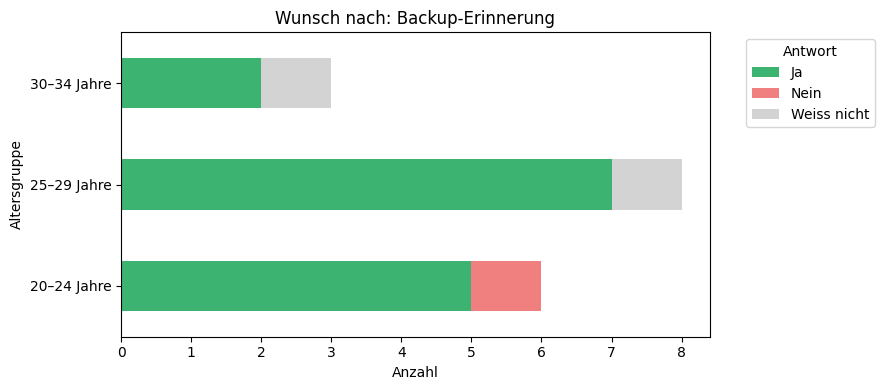

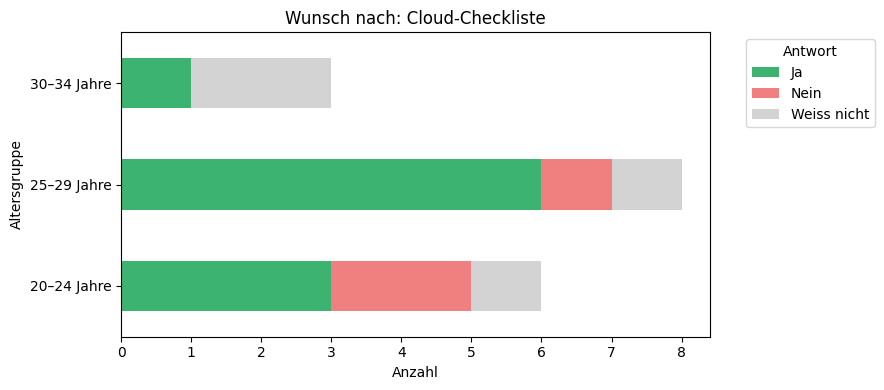

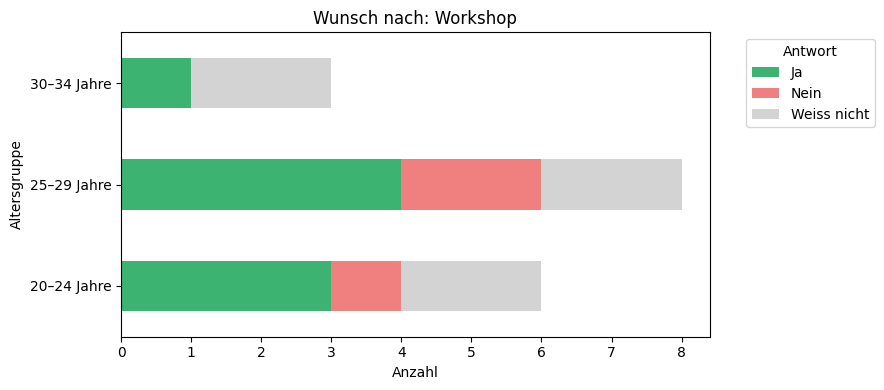

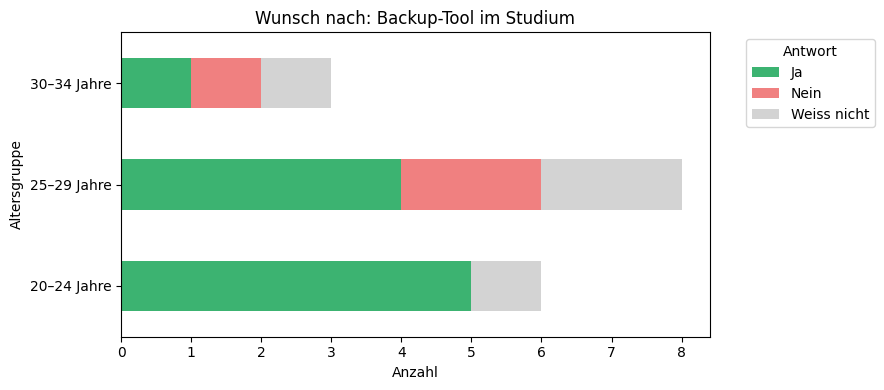

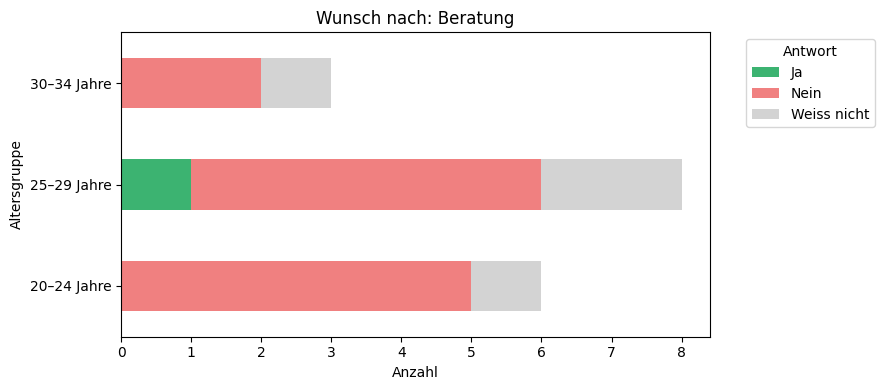

In [24]:
# Spalten: Wunsch zu Angeboten
wuensche_cols = {
    "Backup-Erinnerung": "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Backup-Erinnerung][Skala 2]",
    "Cloud-Checkliste": "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Cloud-Checkliste zur Selbstkontrolle][Skala 2]",
    "Workshop": "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Workshop zur Datensicherheit][Skala 2]",
    "Backup-Tool im Studium": "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Integriertes Backup-Tool im Studium][Skala 2]",
    "Beratung": "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Persönliches Beratungsgespräch][Skala 2]"
}

# Altersgruppen wie gehabt
gruppen_reihenfolge = ["20–24 Jahre", "25–29 Jahre", "30–34 Jahre"]
df["Altersgruppe"] = pd.Categorical(df["Wie alt sind Sie?"], categories=gruppen_reihenfolge, ordered=True)

# Daten aggregieren
wuensche_long = []

for angebot, col in wuensche_cols.items():
    for gruppe in gruppen_reihenfolge:
        subset = df[df["Altersgruppe"] == gruppe]
        antworten = subset[col].value_counts().reindex(["Ja", "Nein", "Weiss nicht"], fill_value=0)
        for antwort, count in antworten.items():
            wuensche_long.append({
                "Angebot": angebot,
                "Antwort": antwort,
                "Altersgruppe": gruppe,
                "Anzahl": count
            })

wuensche_df = pd.DataFrame(wuensche_long)

# Pivotieren: je Angebot ein Plot
for angebot in wuensche_cols.keys():
    data = wuensche_df[wuensche_df["Angebot"] == angebot]
    plot_data = data.pivot(index="Altersgruppe", columns="Antwort", values="Anzahl").fillna(0)
    
    plot_data.plot(kind="barh", stacked=True, figsize=(9,4), 
                   color=["mediumseagreen", "lightcoral", "lightgray"])
    plt.title(f"Wunsch nach: {angebot}")
    plt.xlabel("Anzahl")
    plt.ylabel("Altersgruppe")
    plt.legend(title="Antwort", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


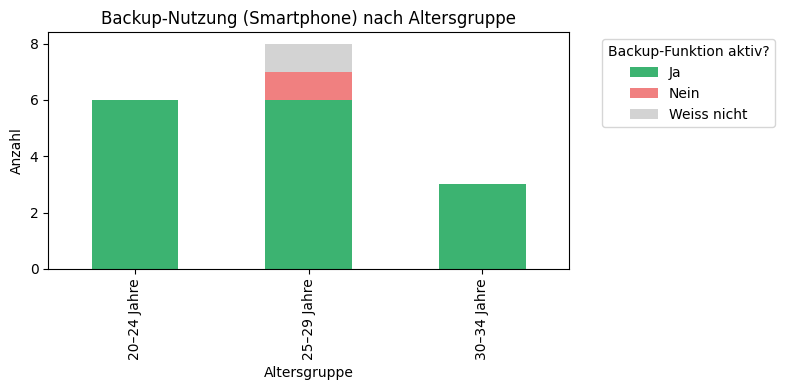

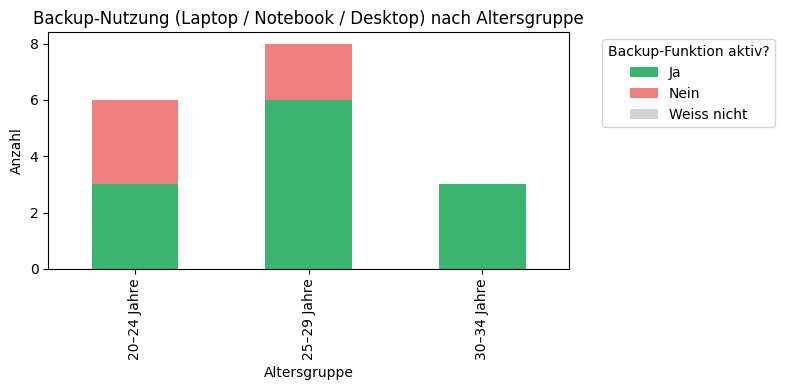

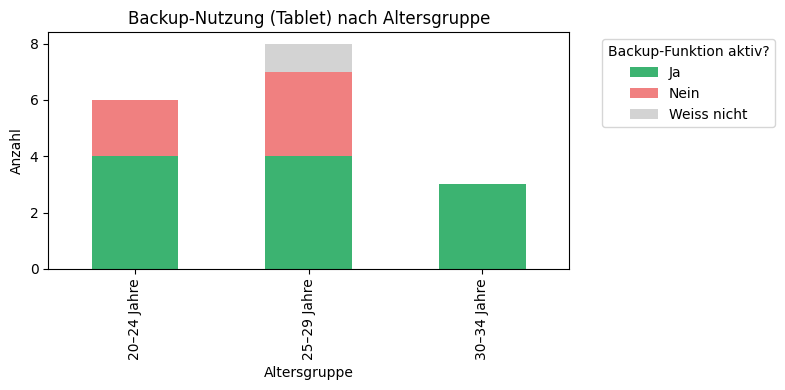

In [25]:
# Relevante Spalten für Backup-Nutzung (Skala 2 je Gerät)
backup_spalten = {
    "Smartphone": "Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Smartphone][Skala 2]",
    "Laptop / Notebook / Desktop": "Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Laptop / Notebook / Desktop][Skala 2]",
    "Tablet": "Welche Gerätetypen verwenden Sie – und mit welchem Betriebssystem hauptsächlich? [Tablet][Skala 2]"
}

# Altersgruppen wie gehabt
gruppen_reihenfolge = ["20–24 Jahre", "25–29 Jahre", "30–34 Jahre"]
df["Altersgruppe"] = pd.Categorical(df["Wie alt sind Sie?"], categories=gruppen_reihenfolge, ordered=True)

# Aggregation vorbereiten
backup_long = []

for geraet, spalte in backup_spalten.items():
    for gruppe in gruppen_reihenfolge:
        daten = df[df["Altersgruppe"] == gruppe]
        verteilung = daten[spalte].value_counts().reindex(["Ja", "Nein", "Weiss nicht"], fill_value=0)
        for antwort, anz in verteilung.items():
            backup_long.append({
                "Gerät": geraet,
                "Altersgruppe": gruppe,
                "Antwort": antwort,
                "Anzahl": anz
            })

# In DataFrame umwandeln
backup_df = pd.DataFrame(backup_long)

# Pivot für Plot
for geraet in backup_spalten.keys():
    data = backup_df[backup_df["Gerät"] == geraet]
    plot_data = data.pivot(index="Altersgruppe", columns="Antwort", values="Anzahl").fillna(0)
    
    plot_data.plot(kind="bar", stacked=True, figsize=(8,4), color=["mediumseagreen", "lightcoral", "lightgray"])
    plt.title(f"Backup-Nutzung ({geraet}) nach Altersgruppe")
    plt.xlabel("Altersgruppe")
    plt.ylabel("Anzahl")
    plt.legend(title="Backup-Funktion aktiv?", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


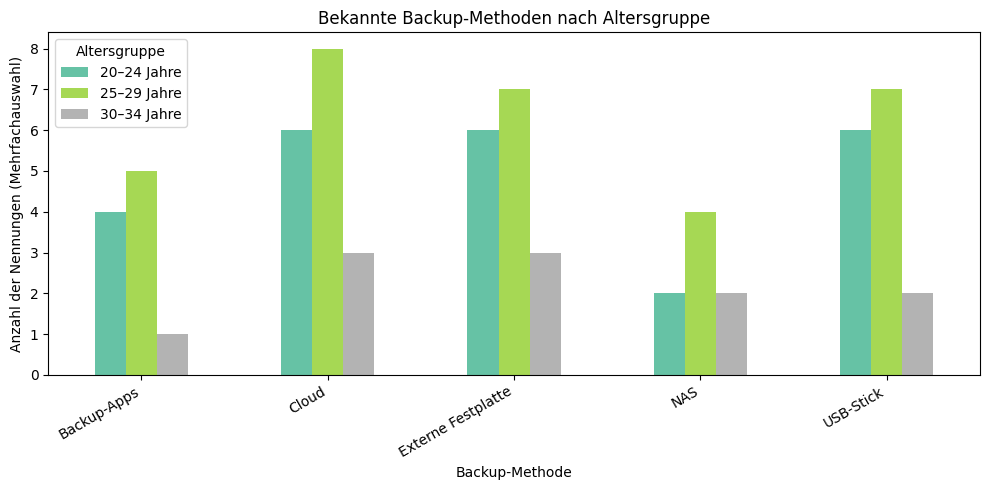

In [26]:
# Spaltenliste Backup-Methoden (Mehrfachauswahl)
methoden_cols = {
    "Externe Festplatte": "Welche Backup-Methoden kennen Sie? [Externe Festplatte]",
    "Cloud": "Welche Backup-Methoden kennen Sie? [Cloud-Speicherung (z.B. iCloud, Google Drive)]",
    "NAS": "Welche Backup-Methoden kennen Sie? [NAS-Systeme]",
    "USB-Stick": "Welche Backup-Methoden kennen Sie? [USB-Stick]",
    "Backup-Apps": "Welche Backup-Methoden kennen Sie? [Backup-Apps auf dem Smartphone]"
}

# Altersgruppen definieren
gruppen_reihenfolge = ["20–24 Jahre", "25–29 Jahre", "30–34 Jahre"]
df["Altersgruppe"] = pd.Categorical(df["Wie alt sind Sie?"], categories=gruppen_reihenfolge, ordered=True)

# Aggregation vorbereiten
backup_methode_long = []

for methode, spalte in methoden_cols.items():
    for gruppe in gruppen_reihenfolge:
        count = df[df["Altersgruppe"] == gruppe][spalte].eq("Ja").sum()
        backup_methode_long.append({
            "Methode": methode,
            "Altersgruppe": gruppe,
            "Anzahl": count
        })

# In DataFrame
backup_methode_df = pd.DataFrame(backup_methode_long)

# Pivot für gruppierten Barplot
pivot_df = backup_methode_df.pivot(index="Methode", columns="Altersgruppe", values="Anzahl").fillna(0)

# Plot
pivot_df.plot(kind="bar", figsize=(10,5), colormap="Set2")
plt.title("Bekannte Backup-Methoden nach Altersgruppe")
plt.ylabel("Anzahl der Nennungen (Mehrfachauswahl)")
plt.xlabel("Backup-Methode")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Altersgruppe")
plt.tight_layout()
plt.show()


In [27]:
from scipy.stats import spearmanr

# Spaltennamen
alter_col = "Wie alt sind Sie?"
wichtigkeit_col = "Wie schätzen Sie Ihre persönliche Haltung zum Thema Datensicherheit ein? [Wie wichtig ist Ihnen das Thema Datensicherheit im Alltag?]"
wissen_col = "Wie schätzen Sie Ihre persönliche Haltung zum Thema Datensicherheit ein? [Wie gut fühlen Sie sich zum Thema Backup informiert?]"

# Altersgruppen kategorisieren
gruppen_reihenfolge = ["20–24 Jahre", "25–29 Jahre", "30–34 Jahre"]
df["Altersgruppe"] = pd.Categorical(df[alter_col], categories=gruppen_reihenfolge, ordered=True)

# Zahlen umwandeln
df[wichtigkeit_col] = pd.to_numeric(df[wichtigkeit_col], errors="coerce")
df[wissen_col] = pd.to_numeric(df[wissen_col], errors="coerce")

# Korrelation pro Altersgruppe
for gruppe in gruppen_reihenfolge:
    daten = df[df["Altersgruppe"] == gruppe][[wichtigkeit_col, wissen_col]].dropna()
    if not daten.empty:
        rho, p = spearmanr(daten[wichtigkeit_col], daten[wissen_col])
        print(f"📊 Altersgruppe {gruppe}: Spearman ρ = {rho:.2f}, p = {p:.3f} (n = {len(daten)})")
    else:
        print(f"⚠️ Altersgruppe {gruppe}: nicht genug Daten für Analyse")


📊 Altersgruppe 20–24 Jahre: Spearman ρ = 0.80, p = 0.056 (n = 6)
📊 Altersgruppe 25–29 Jahre: Spearman ρ = 0.38, p = 0.360 (n = 8)
📊 Altersgruppe 30–34 Jahre: Spearman ρ = -0.87, p = 0.333 (n = 3)


### 📊 Zusammenhang zwischen Wichtigkeit & Wissensstand – nach Altersgruppe

#### 🔍 Ziel der Analyse:
Untersucht wurde, ob es innerhalb verschiedener Altersgruppen einen Zusammenhang gibt zwischen:

- **Wichtigkeit von Datensicherheit im Alltag**
- **Gefühltem Wissensstand zum Thema Backup**

→ Beide Variablen wurden auf einer ordinalen Skala (1–10) erfasst und mittels Spearman-Rangkorrelation (ρ) analysiert.

---

#### 🧠 Ergebnisse:

| Altersgruppe     | Spearman ρ | p-Wert | Interpretation |
|------------------|------------|--------|----------------|
| **20–24 Jahre**  | **0.80**   | 0.056  | **Starker positiver Zusammenhang** – Personen, die Datensicherheit als wichtig empfinden, fühlen sich tendenziell auch besser informiert. Der Zusammenhang ist **nahe an statistischer Signifikanz** (Grenzwert p ≈ 0.05). |
| **25–29 Jahre**  | 0.38       | 0.360  | **Leichter positiver Zusammenhang**, jedoch **nicht signifikant**. Es lässt sich **kein belastbarer Trend** feststellen. |
| **30–34 Jahre**  | –0.87      | 0.333  | **Auffällig negativer Zusammenhang**, aber nur **n = 3** → **statistisch nicht interpretierbar**. |

---

#### 📌 Fazit:

- **Nur bei den 20–24-Jährigen** zeigt sich ein deutlicher Trend: *Je wichtiger die Datensicherheit, desto höher das subjektive Backup-Wissen.*
- In älteren Gruppen fehlt entweder ein klarer Zusammenhang oder es mangelt an ausreichender Fallzahl für fundierte Aussagen.


In [36]:
# backup_analysis_plots_svg.py
# ------------------------------------------------------------
# Liest results-survey648199.csv und erzeugt zwei transparente SVGs:
#   • methods_awareness.svg
#   • data_frequency.svg
# Style: Retro-Terminal (Neon-Grün)

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ---------- TERMINAL-NEON-STYLE ----------------------------------------------
plt.rcParams.update({
    "figure.facecolor": "#000000",   # bleibt im Notebook schwarz – wird später
    "axes.facecolor":   "#000000",   # für SVG aber transparent gesetzt
    "text.color":       "#39FF14",
    "axes.labelcolor":  "#39FF14",
    "xtick.color":      "#39FF14",
    "ytick.color":      "#39FF14",
    "axes.edgecolor":   "#39FF14",
})

CSV_PATH = "results-survey648199.csv"   # unverändert lassen
df = pd.read_csv(CSV_PATH)

# -------------------- 1) BEKANNTHEIT DER METHODEN -----------------------------
method_cols = {
    "Externe HDD":   "Welche Backup-Methoden kennen Sie? [Externe Festplatte]",
    "Cloud":         "Welche Backup-Methoden kennen Sie? [Cloud-Speicherung (z.B. iCloud, Google Drive)]",
    "USB-Stick":     "Welche Backup-Methoden kennen Sie? [USB-Stick]",
    "Smartphone-App":"Welche Backup-Methoden kennen Sie? [Backup-Apps auf dem Smartphone]",
    "NAS":           "Welche Backup-Methoden kennen Sie? [NAS-Systeme]",
}

aware_pct = (
    df[list(method_cols.values())]
      .apply(lambda col: (col.str.strip() == "Ja").mean() * 100)
      .rename({v: k for k, v in method_cols.items()})
      .sort_values(ascending=True)
)

fig1, ax1 = plt.subplots(figsize=(6, 3))
ax1.barh(aware_pct.index, aware_pct.values, color="#39FF14")
ax1.set_xlabel("Bekannt (%)")
ax1.set_title(f"Bekanntheit von Backup-Methoden (n = {len(df)})")
ax1.set_xlim(0, 100)
ax1.grid(axis="x", linestyle="--", alpha=.3, color="#39FF14")

# Hintergrund transparent setzen
fig1.patch.set_facecolor("none")
ax1.set_facecolor("none")

fig1.tight_layout()
fig1.savefig(
    "methods_awareness.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.close(fig1)

# -------------------- 2) BACKUP-HÄUFIGKEIT JE DATENTYP ------------------------
freq_cols = {
    "Fotos":            "Wie häufig sichern Sie folgende Arten von Daten? [Fotos]",
    "Dokumente":        "Wie häufig sichern Sie folgende Arten von Daten? [Dokumente]",
    "Studien­unterl.":  "Wie häufig sichern Sie folgende Arten von Daten? [Studienunterlagen]",
    "Geräte­einstell.": "Wie häufig sichern Sie folgende Arten von Daten? [Geräteeinstellungen]",
}

top2 = ["oft", "sehr häufig"]
freq_pct = (
    df[list(freq_cols.values())]
      .apply(lambda col: col.str.strip().isin(top2).mean() * 100)
      .rename({v: k for k, v in freq_cols.items()})
      .sort_values(ascending=True)
)

fig2, ax2 = plt.subplots(figsize=(6, 3))
ax2.barh(freq_pct.index, freq_pct.values, color="#39FF14")
ax2.set_xlabel("sichern regelmäßig (%)")
ax2.set_title("Backup-Häufigkeit je Datentyp (Top-2-Box)")
ax2.set_xlim(0, 100)
ax2.grid(axis="x", linestyle="--", alpha=.3, color="#39FF14")

fig2.patch.set_facecolor("none")
ax2.set_facecolor("none")

fig2.tight_layout()
fig2.savefig(
    "data_frequency.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.close(fig2)

print("SVGs gespeichert!  →  methods_awareness.svg  |  data_frequency.svg")


SVGs gespeichert!  →  methods_awareness.svg  |  data_frequency.svg


In [6]:
# ========================= 1) KUCHENDIAGRAMM  ================================
# ... aware_pct & PIE_COLORS bleiben identisch ...

fig, ax = plt.subplots(figsize=(4, 4))

wedges, texts, autotexts = ax.pie(
    aware_pct.values,
    labels=aware_pct.index,
    colors=PIE_COLORS[: len(aware_pct)],
    startangle=90,
    autopct=autopct_red(aware_pct.values),
    pctdistance=0.78,
    textprops={"color": "#39FF14", "fontsize": 9},
    wedgeprops=dict(width=0.3)           # Donut-Ring
)

# Prozentlabels rot einfärben
for t in autotexts:
    t.set_color("#FF3131")
    t.set_fontweight("bold")

# -------- TITEL & ASPECT KORREKT SETZEN -------------
ax.set_aspect("equal")                   # statt aspect=… in set()
ax.set_title(
    f"Bekanntheit von Backup-Methoden  n={len(df)}",
    loc="left", pad=12,
    fontfamily="monospace", fontsize=14, fontweight="bold"
)

# Transparenter Hintergrund
fig.patch.set_facecolor("none")
ax.set_facecolor("none")
fig.tight_layout()
fig.savefig(
    "methods_awareness_pie.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.close(fig)


In [13]:
# backup_charts_courierprime.py
# ------------------------------------------------------------
# Erzeugt zwei transparente SVGs:
#   • methods_awareness_pie.svg   (Donut – Bekanntheit)
#   • data_frequency.svg          (Balken – Backup-Häufigkeit)
# Schrift: Courier Prime (lokal aus fonts/ eingebunden)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe
from matplotlib import font_manager as fm
import pathlib
import warnings
warnings.filterwarnings("ignore")

# ───────────────── 1. Courier Prime registrieren ──────────────────────────────
FONT_DIR = pathlib.Path("3WM")  # Updated to use the provided directory
if FONT_DIR.exists():
    for ttf in FONT_DIR.glob("CourierPrime-*.ttf"):
        fm.fontManager.addfont(ttf)
    COURIER_FAMILY = "Courier Prime"
else:
    print("⚠️  Ordner '3WM/' mit Courier-Prime-TTFs nicht gefunden – fallback auf System-Monospace.")
    COURIER_FAMILY = "monospace"

# ───────────────── 2. Globales Neon-Theme ─────────────────────────────────────
plt.rcParams.update({
    "font.family": COURIER_FAMILY,
    "figure.facecolor": "#000000",
    "axes.facecolor":   "#000000",
    "text.color":       "#39FF14",
    "axes.labelcolor":  "#39FF14",
    "xtick.color":      "#39FF14",
    "ytick.color":      "#39FF14",
    "axes.edgecolor":   "#39FF14",
})

# ───────────────── 3. Daten einlesen ──────────────────────────────────────────
CSV_PATH = "results-survey648199.csv"
df = pd.read_csv(CSV_PATH)

# ════════════════════════ 4. DONUT – Bekanntheit ══════════════════════════════
method_cols = {
    "Externe HDD":   "Welche Backup-Methoden kennen Sie? [Externe Festplatte]",
    "Cloud":         "Welche Backup-Methoden kennen Sie? [Cloud-Speicherung (z.B. iCloud, Google Drive)]",
    "USB-Stick":     "Welche Backup-Methoden kennen Sie? [USB-Stick]",
    "Smartphone-App":"Welche Backup-Methoden kennen Sie? [Backup-Apps auf dem Smartphone]",
    "NAS":           "Welche Backup-Methoden kennen Sie? [NAS-Systeme]",
}
aware_pct = (
    df[list(method_cols.values())]
      .apply(lambda c: (c.str.strip() == "Ja").mean()*100)
      .rename({v: k for k, v in method_cols.items()})
      .sort_values(ascending=False)
)
PIE_COLORS = ["#00FFA3", "#00FF82", "#00FF61", "#00FF40", "#00FF1F"]

fig, ax = plt.subplots(figsize=(5, 5))
wedges, texts, autotexts = ax.pie(
    aware_pct.values,
    labels=aware_pct.index,
    colors=PIE_COLORS[: len(aware_pct)],
    startangle=90,
    labeldistance=1.12,       # Außenlabels
    autopct="%1.0f%%",
    pctdistance=0.72,         # Prozent dichter am Ring
    textprops={
        "fontsize": 11,
        "color": "#39FF14",
        "path_effects": [pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()],
    },
    wedgeprops=dict(width=0.45, edgecolor="#000")
)

# Prozentlabels rot + Halo
for t in autotexts:
    t.set_color("#FF3131")
    t.set_fontweight("bold")
    t.set_path_effects([pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()])

ax.set_aspect("equal")   # Kreis bleibt Kreis
ax.set_title("")         # KEIN Titel

# Transparente Ausgabe
fig.patch.set_facecolor("none")
ax.set_facecolor("none")
fig.tight_layout()
fig.savefig(
    "methods_awareness_pie.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.close(fig)

# ═══════════════════ 5. BALKEN – Backup-Häufigkeit ════════════════════════════
freq_cols = {
    "Fotos":            "Wie häufig sichern Sie folgende Arten von Daten? [Fotos]",
    "Dokumente":        "Wie häufig sichern Sie folgende Arten von Daten? [Dokumente]",
    "Studien­unterl.":  "Wie häufig sichern Sie folgende Arten von Daten? [Studienunterlagen]",
    "Geräte­einstell.": "Wie häufig sichern Sie folgende Arten von Daten? [Geräteeinstellungen]",
}
top2 = ["oft", "sehr häufig"]
freq_pct = (
    df[list(freq_cols.values())]
      .apply(lambda c: c.str.strip().isin(top2).mean()*100)
      .rename({v: k for k, v in freq_cols.items()})
      .sort_values(ascending=True)
)
BAR_COLORS = ["#5BFFDF", "#45FFD0", "#2FFFC1", "#19FFB2"]

fig2, ax2 = plt.subplots(figsize=(6, 3))
ax2.barh(freq_pct.index, freq_pct.values, color=BAR_COLORS, alpha=.9, height=.55)

# Prozent in den Balken
for p in ax2.patches:
    w = p.get_width()
    y = p.get_y() + p.get_height()/2
    ax2.text(w - 2, y, f"{w:.0f}%", va="center", ha="right",
             color="#FF3131", fontsize=10, fontweight="bold",
             path_effects=[pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()],
             clip_on=True)

ax2.set_xlim(0, 100)
ax2.set_xticks([])                   # Achse weg
ax2.set_xlabel("")
ax2.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax2.tick_params(axis="y", pad=8)
ax2.set_title("")

fig2.patch.set_facecolor("none")
ax2.set_facecolor("none")
fig2.tight_layout()
fig2.savefig(
    "data_frequency.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.close(fig2)

print("✅ SVGs gespeichert:\n   • methods_awareness_pie.svg\n   • data_frequency.svg")


⚠️  Ordner '3WM/' mit Courier-Prime-TTFs nicht gefunden – fallback auf System-Monospace.
✅ SVGs gespeichert:
   • methods_awareness_pie.svg
   • data_frequency.svg


# Alter

In [6]:
# age_groups_pie_courierprime_print.py
# ------------------------------------------------------------
# SVG-Ausgabe: age_groups_pie.svg  (drucktaugliches Donut-Chart)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib import font_manager as fm
import pathlib, re, warnings
warnings.filterwarnings("ignore")

# ───── 1. Courier Prime registrieren (TTFs in 3WM/) ──────────
FONT_DIR = pathlib.Path("3WM")
if FONT_DIR.exists():
    for ttf in FONT_DIR.glob("CourierPrime-*.ttf"):
        fm.fontManager.addfont(ttf)
    FONT_FAMILY = "Courier Prime"
else:
    print("⚠️  '3WM/' nicht gefunden – fallback auf Monospace.")
    FONT_FAMILY = "monospace"

# Neon-Theme (Texte bleiben unverändert)
plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "figure.facecolor": "#000",
    "axes.facecolor":   "#000",
    "text.color":       "#A5FFB4",     # etwas dunkleres Mint
    "axes.labelcolor":  "#A5FFB4",
    "xtick.color":      "#A5FFB4",
    "ytick.color":      "#A5FFB4",
    "axes.edgecolor":   "#A5FFB4",
})

# ───── 2. CSV laden & Altersgruppen zählen ──────────────────
CSV_PATH = "results-survey648199.csv"
AGE_COL  = "Wie alt sind Sie?"
df = pd.read_csv(CSV_PATH)

age_series = df[AGE_COL].dropna().str.strip()
def sort_key(g): return int(re.match(r"(\d+)", g).group(1))
age_counts = (age_series.value_counts()
              .rename_axis("age_group").reset_index(name="cnt")
              .sort_values(by="age_group", key=lambda s: s.map(sort_key)))
age_counts["pct"] = age_counts["cnt"] / age_counts["cnt"].sum() * 100

# ───── 3. Donut-Chart (druck­optimierte Farben) ─────────────
PRINT_COLORS = ["#009E60", "#00B472", "#24CA83", "#49DF95", "#6BF5A7", "#8AFFB8"]

fig, ax = plt.subplots(figsize=(5, 5))
wedges, lbls, pcts = ax.pie(
    age_counts["pct"],
    labels=age_counts["age_group"],
    colors=PRINT_COLORS[: len(age_counts)],
    startangle=90,
    labeldistance=1.15,            # etwas mehr Abstand
    autopct="%1.0f%%",
    pctdistance=0.75,
    textprops={
        "fontsize": 11,
        "color": "#A5FFB4",
        "path_effects": [pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()],
    },
    wedgeprops=dict(width=0.45, edgecolor="#000")
)

for t in pcts:
    t.set_color("#D43737")         # druck­rotes Rot
    t.set_fontweight("bold")
    t.set_path_effects([pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()])

ax.set_aspect("equal")
ax.set_title("")

# Transparenter Export
fig.patch.set_facecolor("none")
ax.set_facecolor("none")
fig.tight_layout()
fig.savefig(
    "age_groups_pie.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.close(fig)

print("✅ SVG (druckfreundliche Farben) gespeichert: age_groups_pie.svg")


⚠️  '3WM/' nicht gefunden – fallback auf Monospace.
✅ SVG (druckfreundliche Farben) gespeichert: age_groups_pie.svg


In [7]:
# backup_charts_courierprime_print.py
# ------------------------------------------------------------
# • methods_awareness_pie.svg  (drucktauglicher Donut)
# • data_frequency.svg         (drucktauglicher Balken)

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib import font_manager as fm
import pathlib
import warnings
warnings.filterwarnings("ignore")

# ───── 1. Courier Prime registrieren (TTFs in 3WM/) ──────────
FONT_DIR = pathlib.Path("3WM")
if FONT_DIR.exists():
    for ttf in FONT_DIR.glob("CourierPrime-*.ttf"):
        fm.fontManager.addfont(ttf)
    FONT_FAMILY = "Courier Prime"
else:
    print("⚠️  '3WM/' fehlt – fallback auf Monospace.")
    FONT_FAMILY = "monospace"

# ───── 2. Globales Druck-Theme ───────────────────────────────
plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "figure.facecolor": "#000",
    "axes.facecolor":   "#000",
    "text.color":       "#A5FFB4",   # dunkleres Mint
    "axes.labelcolor":  "#A5FFB4",
    "xtick.color":      "#A5FFB4",
    "ytick.color":      "#A5FFB4",
    "axes.edgecolor":   "#A5FFB4",
})

RED_PRINT = "#D43737"                # druckfreundliches Rot
GREEN_BAR = "#24CA83"                # einheitliches, satteres Grün
PRINT_COLORS = ["#009E60", "#00B472", "#24CA83", "#49DF95", "#6BF5A7", "#8AFFB8"]

CSV_PATH = "results-survey648199.csv"
df = pd.read_csv(CSV_PATH)

# ═══════════════════ 3. DONUT – Bekannheit ═══════════════════
method_cols = {
    "Externe HDD":   "Welche Backup-Methoden kennen Sie? [Externe Festplatte]",
    "Cloud":         "Welche Backup-Methoden kennen Sie? [Cloud-Speicherung (z.B. iCloud, Google Drive)]",
    "USB-Stick":     "Welche Backup-Methoden kennen Sie? [USB-Stick]",
    "Smartphone-App":"Welche Backup-Methoden kennen Sie? [Backup-Apps auf dem Smartphone]",
    "NAS":           "Welche Backup-Methoden kennen Sie? [NAS-Systeme]",
}
aware_pct = (
    df[list(method_cols.values())]
      .apply(lambda c: (c.str.strip() == "Ja").mean()*100)
      .rename({v: k for k, v in method_cols.items()})
      .sort_values(ascending=False)
)

fig1, ax1 = plt.subplots(figsize=(5, 5))
wedges, labels, pcts = ax1.pie(
    aware_pct.values,
    labels=aware_pct.index,
    colors=PRINT_COLORS[: len(aware_pct)],
    startangle=90,
    labeldistance=1.15,
    autopct="%1.0f%%",
    pctdistance=0.75,
    textprops={
        "fontsize": 11,
        "color": "#A5FFB4",
        "path_effects": [pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()],
    },
    wedgeprops=dict(width=0.45, edgecolor="#000")
)
for t in pcts:
    t.set_color(RED_PRINT)
    t.set_fontweight("bold")
    t.set_path_effects([pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()])

ax1.set_aspect("equal")
ax1.set_title("")
fig1.patch.set_facecolor("none")
ax1.set_facecolor("none")
fig1.tight_layout()
fig1.savefig(
    "methods_awareness_pie.svg",
    format="svg", transparent=True,
    bbox_inches="tight", pad_inches=0.1
)
plt.close(fig1)

# ═════════════════ 4. BALKEN – Backup-Häufigkeit ═════════════════
freq_cols = {
    "Fotos":            "Wie häufig sichern Sie folgende Arten von Daten? [Fotos]",
    "Dokumente":        "Wie häufig sichern Sie folgende Arten von Daten? [Dokumente]",
    "Studien­unterl.":  "Wie häufig sichern Sie folgende Arten von Daten? [Studienunterlagen]",
    "Geräte­einstell.": "Wie häufig sichern Sie folgende Arten von Daten? [Geräteeinstellungen]",
}
top2 = ["oft", "sehr häufig"]
freq_pct = (
    df[list(freq_cols.values())]
      .apply(lambda c: c.str.strip().isin(top2).mean()*100)
      .rename({v: k for k, v in freq_cols.items()})
      .sort_values(ascending=True)
)

fig2, ax2 = plt.subplots(figsize=(6, 3))
ax2.barh(freq_pct.index, freq_pct.values, color=GREEN_BAR, alpha=.9, height=.55)

for p in ax2.patches:
    w = p.get_width()
    y = p.get_y() + p.get_height()/2
    ax2.text(w - 2, y, f"{w:.0f}%",
             va="center", ha="right",
             color=RED_PRINT, fontsize=10, fontweight="bold",
             path_effects=[pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()],
             clip_on=True)

ax2.set_xlim(0, 100)
ax2.set_xticks([])
ax2.spines[["top", "right", "bottom", "left"]].set_visible(False)
ax2.tick_params(axis="y", pad=8)
ax2.set_title("")
fig2.patch.set_facecolor("none")
ax2.set_facecolor("none")
fig2.tight_layout()
fig2.savefig(
    "data_frequency.svg",
    format="svg", transparent=True,
    bbox_inches="tight", pad_inches=0.1
)
plt.close(fig2)

print("✅ Druckfreundliche SVGs gespeichert:\n   • methods_awareness_pie.svg\n   • data_frequency.svg")


⚠️  '3WM/' fehlt – fallback auf Monospace.
✅ Druckfreundliche SVGs gespeichert:
   • methods_awareness_pie.svg
   • data_frequency.svg


In [18]:
# poster_plots_print.py
# ------------------------------------------------------------
# Erzeugt alle finalen SVGs für das Poster (drucktaugliche Farben).

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib import font_manager as fm
import numpy as np
import pathlib, re, warnings
warnings.filterwarnings("ignore")

# ─────────────────────────── 0) SETUP ─────────────────────────────────────────
FONT_DIR = pathlib.Path("3WM")            # Ordner mit CourierPrime-*.ttf
if FONT_DIR.exists():
    for ttf in FONT_DIR.glob("CourierPrime-*.ttf"):
        fm.fontManager.addfont(ttf)
    FONT_FAMILY = "Courier Prime"
else:
    print("⚠️  '3WM/' fehlt – fallback auf Monospace.")
    FONT_FAMILY = "monospace"

# Druckfreundliche Farbpalette
COL_MINT  = "#A5FFB4"
COL_GREEN = "#24CA83"
COL_DARK  = "#009E60"
COL_RED   = "#D43737"
PRINT_COLORS = ["#009E60", "#00B472", "#24CA83", "#49DF95", "#6BF5A7", "#8AFFB8"]

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "figure.facecolor": "#000",
    "axes.facecolor":   "#000",
    "text.color":       COL_MINT,
    "axes.labelcolor":  COL_MINT,
    "xtick.color":      COL_MINT,
    "ytick.color":      COL_MINT,
    "axes.edgecolor":   COL_MINT,
})

CSV = "results-survey648199.csv"
df  = pd.read_csv(CSV)

# ─────────────────────── 1) DONUT: BEKANNTHEIT ───────────────────────────────
method_cols = {
    "Externe HDD":   "Welche Backup-Methoden kennen Sie? [Externe Festplatte]",
    "Cloud":         "Welche Backup-Methoden kennen Sie? [Cloud-Speicherung (z.B. iCloud, Google Drive)]",
    "USB-Stick":     "Welche Backup-Methoden kennen Sie? [USB-Stick]",
    "Smartphone-App":"Welche Backup-Methoden kennen Sie? [Backup-Apps auf dem Smartphone]",
    "NAS":           "Welche Backup-Methoden kennen Sie? [NAS-Systeme]",
}
aware_pct = (df[list(method_cols.values())]
             .apply(lambda c: (c.str.strip()=="Ja").mean()*100)
             .rename({v:k for k,v in method_cols.items()})
             .sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(5,5))
wedges, lbls, pcts = ax.pie(
    aware_pct.values, labels=aware_pct.index, colors=PRINT_COLORS[:len(aware_pct)],
    startangle=90, labeldistance=1.15, autopct="%1.0f%%", pctdistance=0.75,
    textprops={"fontsize":11,"color":COL_MINT,
               "path_effects":[pe.Stroke(linewidth=2,foreground="#000"),pe.Normal()]},
    wedgeprops=dict(width=0.45,edgecolor="#000"))
for t in pcts:
    t.set_color(COL_RED); t.set_fontweight("bold")
    t.set_path_effects([pe.Stroke(linewidth=2,foreground="#000"),pe.Normal()])
ax.set_aspect("equal"); ax.set_title("")
fig.patch.set_facecolor("none"); ax.set_facecolor("none")
fig.tight_layout(); fig.savefig("methods_awareness_pie.svg",
    format="svg",transparent=True,bbox_inches="tight",pad_inches=0.1)
plt.close(fig)

# ────────────────── 2) BALKEN: BACKUP-HÄUFIGKEIT ─────────────────────────────
freq_cols = {
    "Fotos":            "Wie häufig sichern Sie folgende Arten von Daten? [Fotos]",
    "Dokumente":        "Wie häufig sichern Sie folgende Arten von Daten? [Dokumente]",
    "Studienunterlagen":"Wie häufig sichern Sie folgende Arten von Daten? [Studienunterlagen]",
    "Einstellungen":    "Wie häufig sichern Sie folgende Arten von Daten? [Geräteeinstellungen]",
}
top2 = {"oft","sehr häufig"}
freq_pct = (df[list(freq_cols.values())]
            .apply(lambda c: c.str.strip().isin(top2).mean()*100)
            .rename({v:k for k,v in freq_cols.items()})
            .sort_values())
fig2, ax2 = plt.subplots(figsize=(6,3))
ax2.barh(freq_pct.index,freq_pct.values,color=COL_GREEN,alpha=.9,height=.55)
for p in ax2.patches:
    w=p.get_width(); y=p.get_y()+p.get_height()/2
    ax2.text(w-2,y,f"{w:.0f}%",ha="right",va="center",
             color=COL_RED,fontweight="bold",
             path_effects=[pe.Stroke(linewidth=2,foreground="#000"),pe.Normal()])
ax2.set_xlim(0,100); ax2.set_xticks([])
ax2.spines[["top","right","bottom","left"]].set_visible(False)
ax2.tick_params(axis="y",pad=8); ax2.set_title("")
fig2.patch.set_facecolor("none"); ax2.set_facecolor("none")
fig2.tight_layout(); fig2.savefig("data_frequency.svg",
    format="svg",transparent=True,bbox_inches="tight",pad_inches=0.1)
plt.close(fig2)

# ──────────────── 3) DIVERGING: BARRIEREN & MOTIVATOREN ──────────────────────
BARRIER_COLS = {
    "Ich vergesse Backups":    "Wie sehr stimmen Sie folgenden Aussagen zu? [Ich vergesse oft, regelmässig Backups zu machen]",
    "Einrichtung aufwändig":   "Wie sehr stimmen Sie folgenden Aussagen zu? [Ich empfinde das Einrichten von Backups als zu aufwendig]",
}
MOTIV_COLS = {
    "Sicherheit der Daten":    "Warum machen Sie Backups? [Aus Angst vor Datenverlust]",
    "Automatisch & bequem":    "Warum machen Sie Backups? [Weil mein Gerät das automatisch übernimmt]",
}

barrier_pct = pd.Series({
    k: df[v].isin({"trifft eher zu","trifft teilweise zu"}).mean()*100
    for k,v in BARRIER_COLS.items()
})
motiv_pct = pd.Series({
    k: (df[v].str.strip()=="Ja").mean()*100
    for k,v in MOTIV_COLS.items()
})
bars = pd.concat([-barrier_pct, motiv_pct]).sort_values()
fig3, ax3 = plt.subplots(figsize=(6,3))
colors=[COL_RED if v<0 else COL_GREEN for v in bars]
ax3.barh(bars.index,bars.values,color=colors,alpha=.9)
# Prozent-Label an den Balken – mit Offset in Points, kein Überlappen mehr
# Prozent-Labels IN den Balken zentrieren
for y, v in enumerate(bars.values):
    ax3.annotate(
        f"{abs(v):.0f}%",                  # Text
        xy=(v / 2, y),                     # Mitte des Balkens
        va="center",
        ha="center",
        color="#000000",                   # schwarz hebt sich auf Rot & Grün ab
        fontweight="bold",
        path_effects=[                     # dünner Halo für bessere Lesbarkeit
            pe.Stroke(linewidth=2, foreground="#FFFFFF"),
            pe.Normal()
        ],
    )


ax3.axvline(0,color=COL_MINT,lw=.8)
ax3.set_xticks([]); ax3.spines[["top","right","bottom","left"]].set_visible(False)
fig3.patch.set_facecolor("none"); ax3.set_facecolor("none")
fig3.tight_layout(); fig3.savefig("barriers_motivators.svg",
    format="svg",transparent=True,bbox_inches="tight",pad_inches=0.1)
plt.close(fig3)

# ──────────────── 4) STACKED: FREQUENZEN × DATENTYP ──────────────────────────
ORDER = ["sehr häufig","oft","manchmal","selten","nie"]
stack_df = (df[list(freq_cols.values())]
            .apply(lambda c: c.str.strip().value_counts(normalize=True)*100)
            .reindex(ORDER).fillna(0)
            .rename(columns={v:k for k,v in freq_cols.items()}))
fig4, ax4 = plt.subplots(figsize=(6,3))
bottom=np.zeros(len(stack_df.columns))
stack_colors=[COL_GREEN,"#3BCB8B","#58D8A0","#74E4B3","#90F0C6"]
for i,label in enumerate(ORDER):
    vals=stack_df.loc[label].values
    ax4.barh(stack_df.columns,vals,left=bottom,color=stack_colors[i],edgecolor="#000",alpha=.9)
    bottom+=vals
    # Prozentlabels (>15 %)
    for j,val in enumerate(vals):
        if val>=15:
            ax4.text(bottom[j]-val/2,j,f"{val:.0f}%",ha="center",va="center",
                     fontsize=8,color="#000",fontweight="bold")
ax4.set_xlim(0,100); ax4.set_xticks([])
ax4.spines[["top","right","bottom","left"]].set_visible(False)
ax4.tick_params(axis="y",pad=6)
fig4.patch.set_facecolor("none"); ax4.set_facecolor("none")
fig4.tight_layout(); fig4.savefig("frequency_stacked.svg",
    format="svg",transparent=True,bbox_inches="tight",pad_inches=0.1)
plt.close(fig4)

# ─────────────── 5) EXPERIENCE ↔ VERHALTEN (AUTO-DETECT) ─────────────────────
# Likert-Mapping
LIKERT_MAP = {"nie":1,"selten":2,"manchmal":3,"oft":4,"sehr häufig":5}
# auto-detect experience col
exp_pattern=re.compile(r"backup.*(studium|unterricht|job)",re.I)
exp_candidates=[c for c in df.columns if exp_pattern.search(c)]
if not exp_candidates:
    raise ValueError("Keine Experience-Spalte gefunden – pattern anpassen!")
EXP_COL=exp_candidates[0]; print(f"⚙️  nutze Experience-Spalte: {EXP_COL}")

DOC_FREQ_COL = "Wie häufig sichern Sie folgende Arten von Daten? [Dokumente]"
df["exp"]=df[EXP_COL].str.contains(r"Ja|trifft.*zu|bereits",case=False,na=False)
df["doc_score"]=df[DOC_FREQ_COL].str.strip().map(LIKERT_MAP)

means=(df.groupby("exp")["doc_score"].mean()
       .rename({False:"Ohne\nVorerf.",True:"Mit\nVorerf."}))
fig5, ax5 = plt.subplots(figsize=(3.5,3))
ax5.bar(means.index,means.values,color=[COL_DARK,COL_GREEN],width=0.6)
for x,v in enumerate(means.values):
    ax5.text(x,v+0.05,f"{v:.2f}",ha="center",va="bottom",
             color=COL_RED,fontweight="bold",
             path_effects=[pe.Stroke(linewidth=2,foreground="#000"),pe.Normal()])
ax5.set_ylim(0,5.5); ax5.set_yticks([])
ax5.spines[["top","right","left"]].set_visible(False)
ax5.spines["bottom"].set_color(COL_MINT)
fig5.patch.set_facecolor("none"); ax5.set_facecolor("none")
fig5.tight_layout(); fig5.savefig("experience_effect.svg",
    format="svg",transparent=True,bbox_inches="tight",pad_inches=0.1)
plt.close(fig5)

print("✅ Alle SVGs erstellt:")
print("   • methods_awareness_pie.svg")
print("   • data_frequency.svg")
print("   • barriers_motivators.svg")
print("   • frequency_stacked.svg")
print("   • experience_effect.svg")


⚠️  '3WM/' fehlt – fallback auf Monospace.
⚙️  nutze Experience-Spalte: Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Integriertes Backup-Tool im Studium][Skala 1]
✅ Alle SVGs erstellt:
   • methods_awareness_pie.svg
   • data_frequency.svg
   • barriers_motivators.svg
   • frequency_stacked.svg
   • experience_effect.svg


In [19]:
# fazit_kpis.py
# ------------------------------------------------------------
# Output: fazit_kpis.svg  (drei Mini-KPI-Donuts für den Fazit-Block)

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib import font_manager as fm
import numpy as np
import pathlib, warnings
warnings.filterwarnings("ignore")

# --- 0) Courier Prime registrieren (3WM/) --------------------
FONT_DIR = pathlib.Path("3WM")
if FONT_DIR.exists():
    for ttf in FONT_DIR.glob("CourierPrime-*.ttf"):
        fm.fontManager.addfont(ttf)
    FONT_FAMILY = "Courier Prime"
else:
    FONT_FAMILY = "monospace"

plt.rcParams.update({
    "font.family": FONT_FAMILY,
    "figure.facecolor": "#000",
    "axes.facecolor":   "#000",
    "text.color":       "#A5FFB4",
})

# --- 1) KPI-Daten -------------------------------------------
kpis = [
    {"label": "Safety\nfirst", "value": 94, "color": "#24CA83"},   # Grün
    {"label": "Aufwand",      "value": 59, "color": "#D43737"},   # Rot
    {"label": "Lehre\nwirkt", "value": 20, "color": "#8AFFB8"},   # Mint
]

# --- 2) Plot -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(9, 3), subplot_kw={"aspect":"equal"})
for ax, k in zip(axes, kpis):
    # Grund-Donut (100 %) – heller Ring
    ax.pie([1], radius=1, colors=["#222"], wedgeprops=dict(width=0.25, edgecolor="#000"))
    # Wert-Segment
    ax.pie(
        [k["value"], 100-k["value"]],
        radius=1,
        startangle=90,
        colors=[k["color"], "none"],
        wedgeprops=dict(width=0.25, edgecolor="#000")
    )
    # Text im Zentrum
    ax.text(0, 0.05, f"{k['value']:.0f}%", ha="center", va="center",
            fontsize=16, fontweight="bold", color=k["color"],
            path_effects=[pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()])
    ax.text(0, -0.5, k["label"], ha="center", va="center",
            fontsize=9, color="#A5FFB4", linespacing=1.2)
    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title("")

fig.subplots_adjust(wspace=0.6)
fig.patch.set_facecolor("none")

fig.savefig("fazit_kpis.svg",
            format="svg",
            transparent=True,
            bbox_inches="tight",
            pad_inches=0.1)
plt.close(fig)

print("✅ KPI-SVG gespeichert: fazit_kpis.svg")


✅ KPI-SVG gespeichert: fazit_kpis.svg


In [20]:
# sankey_mini.py
import matplotlib.pyplot as plt, matplotlib.patheffects as pe
from matplotlib.sankey import Sankey
from matplotlib import font_manager as fm
import pathlib, warnings; warnings.filterwarnings("ignore")

# Courier Prime registrieren
for ttf in pathlib.Path("3WM").glob("CourierPrime-*.ttf"):
    fm.fontManager.addfont(ttf)
plt.rcParams["font.family"] = "Courier Prime"
plt.rcParams["figure.facecolor"] = plt.rcParams["axes.facecolor"] = "#000"

COL_MINT="#A5FFB4"; COL_GREEN="#24CA83"; COL_RED="#D43737"

fig = plt.figure(figsize=(4,3))
sankey = Sankey(fig, unit=None, shoulder=0.02, gap=0.2)
sankey.add(flows=[+0.75,-0.75], labels=['Vorerfahrung','Backup “oft+”'],
           orientations=[0,0], facecolor=COL_GREEN, edgecolor="#000")
sankey.add(flows=[+0.55,-0.55], labels=['Keine Vorerf.','Backup “oft+”'],
           orientations=[0,0], facecolor=COL_RED, edgecolor="#000",
           prior=0, connect=(1,0))        # verbindet zur selben Senke
sankey.finish()
plt.axis('off')
fig.patch.set_facecolor("none")
fig.savefig("sankey_experience.svg", format="svg", transparent=True,
            bbox_inches="tight", pad_inches=0.1)


AttributeError: 'Figure' object has no attribute 'add_patch'

<Figure size 400x300 with 0 Axes>

findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font famil

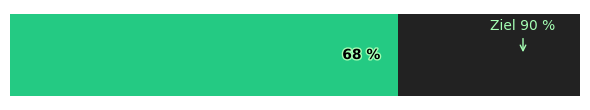

In [21]:
# progress_bar.py
import matplotlib.pyplot as plt, matplotlib.patheffects as pe
from matplotlib import font_manager as fm
import pathlib, warnings; warnings.filterwarnings("ignore")

for ttf in pathlib.Path("3WM").glob("CourierPrime-*.ttf"):
    fm.fontManager.addfont(ttf)
plt.rcParams.update({"font.family":"Courier Prime",
                    "figure.facecolor":"#000","axes.facecolor":"#000",
                    "text.color":"#A5FFB4"})

LEVEL=68                                # Ist-Wert
TARGET=90                               # Wunsch

fig, ax = plt.subplots(figsize=(6,1.2))
ax.barh(0, 100, color="#222", height=0.4)
ax.barh(0, LEVEL, color="#24CA83", height=0.4)
ax.text(LEVEL-3,0,f"{LEVEL} %",va="center",ha="right",
        color="#000",fontweight="bold",
        path_effects=[pe.Stroke(linewidth=2,foreground="#A5FFB4"),pe.Normal()])
ax.annotate("Ziel 90 %", xy=(TARGET,0), xytext=(0,18),
            textcoords="offset points", ha="center",
            arrowprops=dict(arrowstyle="->", color="#A5FFB4"))
ax.set_xlim(0,100); ax.set_yticks([]); ax.set_xticks([])
ax.spines[["top","right","bottom","left"]].set_visible(False)
fig.patch.set_facecolor("none"); ax.set_facecolor("none")
fig.tight_layout(); fig.savefig("progress_reifegrad.svg",
    format="svg", transparent=True, bbox_inches="tight", pad_inches=0.1)


findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.


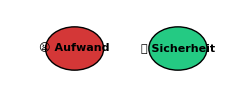

In [22]:
# pain_gain_badges.py
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import pathlib; [fm.fontManager.addfont(ttf) for ttf in pathlib.Path("3WM").glob("CourierPrime-*.ttf")]
plt.rcParams.update({"font.family":"Courier Prime","figure.facecolor":"none"})

fig, ax = plt.subplots(figsize=(3,1))
labels = ["😫 Aufwand", "🛡 Sicherheit"]
colors = ["#D43737","#24CA83"]
for i,(lab,col) in enumerate(zip(labels,colors)):
    circ = plt.Circle((i*1.6,0),0.45,color=col,ec="#000")
    ax.add_patch(circ)
    ax.text(i*1.6,0,lab,ha="center",va="center",color="#000",fontsize=8,
            fontweight="bold")
ax.set_xlim(-1,2.6); ax.set_ylim(-0.8,0.8)
ax.axis('off')
fig.savefig("pain_gain_badges.svg",format="svg",transparent=True,
            bbox_inches="tight",pad_inches=0.1)


In [25]:
# sankey_mini_fixed.py
import matplotlib.pyplot as plt, matplotlib.patheffects as pe
from matplotlib.sankey import Sankey
from matplotlib import font_manager as fm
import pathlib, warnings
warnings.filterwarnings("ignore")

# Courier Prime
for ttf in pathlib.Path("3WM").glob("CourierPrime-*.ttf"):
    fm.fontManager.addfont(ttf)
plt.rcParams["font.family"] = "Courier Prime"
plt.rcParams["figure.facecolor"] = plt.rcParams["axes.facecolor"] = "#000"

COL_MINT="#A5FFB4"; COL_GREEN="#24CA83"; COL_RED="#D43737"

fig, ax = plt.subplots(figsize=(4, 3), subplot_kw={"aspect":"equal"})
s = Sankey(ax=ax, unit=None, shoulder=0.02, gap=0.30)

# Block 1 – mit Vorerfahrung
s.add(flows=[+0.75, -0.75],
      labels=["Vorerf.", "Backup ‘oft+’"],
      orientations=[0, 0],
      facecolor=COL_GREEN, edgecolor="#000")

# Block 2 – ohne Vorerfahrung
s.add(flows=[+0.55, -0.55],
      labels=["Ohne Vorerf.", "Backup ‘oft+’"],
      orientations=[0, 0],
      facecolor=COL_RED, edgecolor="#000")

s.finish()
ax.axis("off")
fig.patch.set_facecolor("none")
fig.savefig("sankey_experience.svg",
            format="svg", transparent=True,
            bbox_inches="tight", pad_inches=0.1)

plt.close(fig)

print("✅ sankey_experience.svg gespeichert")


findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.


findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.
findfont: Font family 'Courier Prime' not found.


✅ sankey_experience.svg gespeichert


In [28]:
# support_wishes.py
# ------------------------------------------------------------
# 1) Prozent "Ja" für zwei Unterstützungsmaßnahmen
# 2) Mini-Progress-Bars als SVG (druckfreundliche Farben)

import pandas as pd, matplotlib.pyplot as plt, matplotlib.patheffects as pe
from matplotlib import font_manager as fm
import pathlib, warnings; warnings.filterwarnings("ignore")

# ── Courier Prime laden (Ordner 3WM/) ─────────────────────────
FONT_DIR = pathlib.Path("3WM")
for ttf in FONT_DIR.glob("CourierPrime-*.ttf"):
    fm.fontManager.addfont(ttf)
plt.rcParams.update({
    "font.family": "Courier Prime" if FONT_DIR.exists() else "monospace",
    "figure.facecolor": "#000", "axes.facecolor": "#000",
    "text.color": "#A5FFB4"
})

# ── Spalten aus deinem CSV ───────────────────────────────────
CSV = "results-survey648199.csv"
df  = pd.read_csv(CSV)

SUPPORT_COLS = {
    "Backup-Tool im Studium":
        "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Integriertes Backup-Tool im Studium][Skala 2]",
    "Backup-Erinnerung":
        "Wie wichtig sind Ihnen folgende Angebote – und wünschen Sie sich diese konkret? [Backup-Erinnerung][Skala 2]",
}

# ── Prozent Ja berechnen ────────────────────────────────────
support_pct = {
    label: (df[col].str.strip() == "Ja").mean()*100
    for label, col in SUPPORT_COLS.items()
}

print("Ergebnisse:")
for k, v in support_pct.items():
    print(f"  {k:25} {v:4.1f} %")

# ── Mini-Progress-SVG erzeugen ──────────────────────────────
COL_BAR  = "#24CA83"   # Grün
COL_TEXT = "#D43737"   # Rot fürs %-Text (guter Kontrast)

fig, axes = plt.subplots(2, 1, figsize=(6, 2.2))
for ax, (label, pct) in zip(axes, support_pct.items()):
    ax.barh(0, 100, color="#222", height=0.35)
    ax.barh(0, pct, color=COL_BAR, height=0.35)
    ax.text(pct-2, 0, f"{pct:.0f}%", ha="right", va="center",
            color=COL_TEXT, fontweight="bold",
            path_effects=[pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()])
    ax.text(0, -0.45, label, ha="left", va="center",
            color="#A5FFB4", fontsize=9)
    ax.set_xlim(0, 100); ax.set_xticks([]); ax.set_yticks([])
    ax.spines[["top","right","bottom","left"]].set_visible(False)

fig.subplots_adjust(hspace=0.8)
fig.patch.set_facecolor("none")
fig.savefig("support_wishes.svg", format="svg",
            transparent=True, bbox_inches="tight", pad_inches=0.1)
plt.close(fig)

print("✅ SVG gespeichert: support_wishes.svg")


Ergebnisse:
  Backup-Tool im Studium    58.8 %
  Backup-Erinnerung         82.4 %
✅ SVG gespeichert: support_wishes.svg


In [29]:
# backup_awareness_from_csv.py
# ------------------------------------------------------------
# • Liest results-survey648199.csv
# • Sucht Spalte "aktiv Infos zu Backups" (RegEx)
# • Erstellt SVG: backup_awareness.svg (druckfreundlicher Neon-Look)

import pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe, matplotlib.font_manager as fm
import pathlib, re, warnings
warnings.filterwarnings("ignore")

# ───── 0) Courier Prime laden (Ordner 3WM/) ──────────────────
FONT_DIR = pathlib.Path("3WM")
for ttf in FONT_DIR.glob("CourierPrime-*.ttf"):
    fm.fontManager.addfont(ttf)
plt.rcParams.update({
    "font.family"     : "Courier Prime" if FONT_DIR.exists() else "monospace",
    "figure.facecolor": "#000",
    "axes.facecolor"  : "#000",
    "text.color"      : "#A5FFB4",
})

# ───── 1) CSV laden & Spalte finden ──────────────────────────
CSV = "results-survey648199.csv"
df  = pd.read_csv(CSV)

SEARCH_PATTERN = re.compile(r"aktiv.*(infos|information).*backup", re.I)

cand = [c for c in df.columns if SEARCH_PATTERN.search(c)]
if not cand:
    raise ValueError(
        "❗️Keine Spalte für 'aktiv nach Infos zu Backups gesucht' gefunden.\n"
        "› Passe SEARCH_PATTERN an oder setze AWARE_COL manuell! «"
    )
AWARE_COL = cand[0]          # erster Treffer
print(f"⚙️  verwende Spalte: {AWARE_COL}")

# ───── 2) Prozent Ja berechnen ───────────────────────────────
aware_pct = (df[AWARE_COL].str.strip().eq("Ja").mean() * 100).round(1)
print(f"→ Backup-Bewusstsein: {aware_pct:.1f} %")

# ───── 3) KPI-Donut plotten ─────────────────────────────────
COL_VAL   = "#24CA83"   # Grün
COL_REST  = "#222"
COL_TEXT  = "#D43737"   # Rot

fig, ax = plt.subplots(figsize=(3, 3), subplot_kw={"aspect":"equal"})

# Hintergrund-Ring
ax.pie([1], radius=1, colors=[COL_REST],
       wedgeprops=dict(width=0.25, edgecolor="#000"))

# Wert-Segment
ax.pie([aware_pct, 100-aware_pct], radius=1,
       startangle=90,
       colors=[COL_VAL, "none"],
       wedgeprops=dict(width=0.25, edgecolor="#000"))

# Text
ax.text(0, 0.05, f"{aware_pct:.0f}%", ha="center", va="center",
        fontsize=18, fontweight="bold", color=COL_TEXT,
        path_effects=[pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()])
ax.text(0, -0.5, "Backup-\nBewusstsein", ha="center", va="center",
        fontsize=9, color="#A5FFB4", linespacing=1.2)

ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
ax.axis("off")
fig.patch.set_facecolor("none")

fig.savefig("backup_awareness.svg",
            format="svg", transparent=True,
            bbox_inches="tight", pad_inches=0.1)
plt.close(fig)

print("✅ SVG gespeichert: backup_awareness.svg")


⚙️  verwende Spalte: Haben Sie jemals aktiv Informationen zum Thema Backup gesucht?
→ Backup-Bewusstsein: 88.2 %
✅ SVG gespeichert: backup_awareness.svg


In [30]:
# backup_awareness_from_csv.py
# ------------------------------------------------------------
# Liest CSV, berechnet Ja-Anteil bei
# »Haben Sie jemals aktiv Informationen …?«
# und erzeugt einen KPI-Donut (SVG).

import pandas as pd, matplotlib.pyplot as plt
import matplotlib.patheffects as pe, matplotlib.font_manager as fm
import pathlib, warnings
warnings.filterwarnings("ignore")

# ── Courier Prime laden (Ordner 3WM/) ────────────────────────
FONT_DIR = pathlib.Path("3WM")
for ttf in FONT_DIR.glob("CourierPrime-*.ttf"):
    fm.fontManager.addfont(ttf)
plt.rcParams.update({
    "font.family": "Courier Prime" if FONT_DIR.exists() else "monospace",
    "figure.facecolor": "#000", "axes.facecolor": "#000",
    "text.color": "#A5FFB4",
})

# ── CSV laden & Spalte setzen ───────────────────────────────
CSV       = "results-survey648199.csv"           # ggf. anpassen
AWARE_COL = "Haben Sie jemals aktiv Informationen zum Thema Backup gesucht?"

df = pd.read_csv(CSV)

# ── Prozent Ja berechnen ───────────────────────────────────
aware_pct = (df[AWARE_COL].str.strip().eq("Ja").mean()*100).round(1)
print(f"Backup-Bewusstsein: {aware_pct:.1f} % (Ja)")

# ── KPI-Donut zeichnen ─────────────────────────────────────
COL_VAL  = "#24CA83"   # Grün
COL_REST = "#222"
COL_TXT  = "#D43737"   # Rot

fig, ax = plt.subplots(figsize=(3,3), subplot_kw={"aspect":"equal"})

# Grund-Ring
ax.pie([1], radius=1, colors=[COL_REST],
       wedgeprops=dict(width=0.25, edgecolor="#000"))

# Wert-Ring
ax.pie([aware_pct, 100-aware_pct], radius=1, startangle=90,
       colors=[COL_VAL, "none"],
       wedgeprops=dict(width=0.25, edgecolor="#000"))

# Zentrum-Text
ax.text(0, 0.05, f"{aware_pct:.0f}%", ha="center", va="center",
        fontsize=18, fontweight="bold", color=COL_TXT,
        path_effects=[pe.Stroke(linewidth=2, foreground="#000"), pe.Normal()])
ax.text(0, -0.55, "Backup-\nBewusstsein", ha="center", va="center",
        fontsize=9, color="#A5FFB4", linespacing=1.2)

ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.2,1.2)
ax.axis("off")
fig.patch.set_facecolor("none")

fig.savefig("backup_awareness.svg", format="svg",
            transparent=True, bbox_inches="tight", pad_inches=0.1)
plt.close(fig)

print("✅ SVG gespeichert: backup_awareness.svg")


Backup-Bewusstsein: 88.2 % (Ja)
✅ SVG gespeichert: backup_awareness.svg


In [31]:
# support_matrix_svg.py
# ------------------------------------------------------------
# 1) liest results-survey648199.csv
# 2) berechnet
#    • Ø-Wichtigkeit  (Skala-1-Spalte, 1–5)
#    • Wunsch-Quote  (Skala-2-Spalte, Ja/Nein)
# 3) baut gruppierte Balken als SVG  →  support_matrix.svg

import pandas as pd, matplotlib.pyplot as plt, matplotlib.patheffects as pe
from matplotlib import font_manager as fm
import pathlib, re, warnings
warnings.filterwarnings("ignore")

# ── Courier Prime laden (3WM/) ───────────────────────────────
FONT_DIR = pathlib.Path("3WM")
for ttf in FONT_DIR.glob("CourierPrime-*.ttf"):
    fm.fontManager.addfont(ttf)
plt.rcParams.update({
    "font.family": "Courier Prime" if FONT_DIR.exists() else "monospace",
    "figure.facecolor": "#000", "axes.facecolor": "#000",
    "text.color": "#A5FFB4"
})

# ── CSV einlesen ─────────────────────────────────────────────
CSV = "results-survey648199.csv"
df  = pd.read_csv(CSV)

# ── Support-Spalten sammeln ─────────────────────────────────
imp_cols  = [c for c in df.columns if "[Skala 1]" in c and "wünschen Sie" in c]
wish_cols = [c for c in df.columns if "[Skala 2]" in c and "wünschen Sie" in c]

# Titel aus Spalten extrahieren
def get_item(col): return re.search(r"\[(.*?)\]\[Skala", col).group(1)

items = [get_item(c) for c in imp_cols]

# Likert-Mapping (1–5)
LIKERT = {"völlig unwichtig":1, "eher unwichtig":2,
          "teils/teils":3,      "eher wichtig":4,  "sehr wichtig":5}

imp_mean  = {}
wish_pct  = {}

for item, imp_col in zip(items, imp_cols):
    imp_mean[item] = df[imp_col].map(LIKERT).mean()

for item, wish_col in zip(items, wish_cols):
    wish_pct[item] = (df[wish_col].str.strip()=="Ja").mean()*100

# ── DatenFrame für Plot ─────────────────────────────────────
plot_df = pd.DataFrame({
    "Wichtigkeit (%)": {k: v/5*100 for k, v in imp_mean.items()},
    "Wunsch (%)": wish_pct
}).round(1).sort_values("Wichtigkeit (%)", ascending=True)

# ── Plot ────────────────────────────────────────────────────
COL_IMP  = "#8AFFB8"   # Mint
COL_WISH = "#24CA83"   # Grün
labels   = plot_df.index

fig, ax = plt.subplots(figsize=(7, 3.5))
y = range(len(labels))

bar1 = ax.barh(y, plot_df["Wichtigkeit (%)"],     height=.35,
               color=COL_IMP,  edgecolor="#000", label="Ø Wichtigkeit")
bar2 = ax.barh([i+0.4 for i in y], plot_df["Wunsch (%)"], height=.35,
               color=COL_WISH, edgecolor="#000", label="Wunsch (Ja)")

# Werte in die Balken
for bars, color in [(bar1,"#000"), (bar2,"#000")]:
    for b in bars:
        w = b.get_width()
        ax.text(w-2, b.get_y()+b.get_height()/2,
                f"{w:.0f}%", ha="right", va="center",
                color=color, fontweight="bold",
                path_effects=[pe.Stroke(linewidth=2, foreground="#A5FFB4"), pe.Normal()])

# Achsen & Style
ax.set_yticks([i+0.2 for i in y]); ax.set_yticklabels(labels)
ax.set_xlim(0, 100); ax.set_xticks([])
ax.spines[["top","right","bottom","left"]].set_visible(False)
ax.legend(loc="lower right", frameon=False, fontsize=8, labelcolor="#A5FFB4")
fig.patch.set_facecolor("none"); ax.set_facecolor("none")
fig.tight_layout()
fig.savefig("support_matrix.svg", format="svg",
            transparent=True, bbox_inches="tight", pad_inches=0.1)
plt.close(fig)

print("✅ SVG gespeichert: support_matddrix.svg")


✅ SVG gespeichert: support_matddrix.svg
